#  Proyecto Final – Detección de Fraude y Retención de Clientes

##  Integrantes del equipo
- **Díaz Salazar, Luis Jaime**
- **Zuluaga Parra, Sara Nicol**
- **Ussa Silva, Diego Alejandro**
- **Guevara Vélez, Manuela**
- **Garzón Rocha, Juan Camilo**
- **Lacouture Daza, Juan Andrés**


In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from scipy.stats import mstats
import warnings; warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
sns.set_theme()

In [78]:
file_name = 'synthetic_fraud_dataset.csv'
df = pd.read_csv(file_name)

df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


# 🔍 Análisis Exploratorio de Datos (EDA)


In [79]:
print(df.shape)

(50000, 21)


- 50 000 filas (transacciones registradas)
- 40 columnas (variables disponibles del dataset)

In [80]:
print(df.head())

  Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0      TXN_33553  USER_1834               39.79              POS   
1       TXN_9427  USER_7875                1.19    Bank Transfer   
2        TXN_199  USER_2734               28.96           Online   
3      TXN_12447  USER_2617              254.32   ATM Withdrawal   
4      TXN_39489  USER_2014               31.28              POS   

             Timestamp  Account_Balance Device_Type  Location  \
0  2023-08-14 19:30:00         93213.17      Laptop    Sydney   
1  2023-06-07 04:01:00         75725.25      Mobile  New York   
2  2023-06-20 15:25:00          1588.96      Tablet    Mumbai   
3  2023-12-07 00:31:00         76807.20      Tablet  New York   
4  2023-11-11 23:44:00         92354.66      Mobile    Mumbai   

  Merchant_Category  IP_Address_Flag  Previous_Fraudulent_Activity  \
0            Travel                0                             0   
1          Clothing                0                        

- Información básica de cada transacción (ID, usuario, monto, fecha, saldo).
- Variables numéricas como Risk_Score y Transaction_Distance.
- Variables categóricas ya convertidas en dummies (método de pago, dispositivo, ubicación, categoría del comercio, autenticación).
- La variable objetivo  Fraud_Label (0 = no fraude, 1 = fraude).

Esta vista nos ayuda a entender la estructura general del dataset y el tipo de información disponible.

In [81]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F


- El dataset tiene 50 000 filas y 40 columnas.
- No hay datos faltantes, todas las columnas tienen 50 000 registros.
- Hay 3 columnas tipo texto (object): Transaction_ID, User_ID, Timestamp.
- Hay 5 columnas numéricas continuas (float).
- Hay 32 columnas numéricas enteras (int64), incluyendo las variables dummies.
- El dataset ocupa cerca de 15 MB de memoria.

Esta salida sirve para entender qué tipo de datos tiene cada columna y si existen valores nulos.


In [82]:
print(df.describe())

       Transaction_Amount  Account_Balance  IP_Address_Flag  \
count        50000.000000     50000.000000      50000.00000   
mean            99.411012     50294.065981          0.05020   
std             98.687292     28760.458557          0.21836   
min              0.000000       500.480000          0.00000   
25%             28.677500     25355.995000          0.00000   
50%             69.660000     50384.430000          0.00000   
75%            138.852500     75115.135000          0.00000   
max           1174.140000     99998.310000          1.00000   

       Previous_Fraudulent_Activity  Daily_Transaction_Count  \
count                  50000.000000             50000.000000   
mean                       0.098400                 7.485240   
std                        0.297858                 4.039637   
min                        0.000000                 1.000000   
25%                        0.000000                 4.000000   
50%                        0.000000             


- Transaction_Amount tiene un promedio cercano a 98, con gran variación entre compras pequeñas y transacciones de más de 400.
- Account_Balance tiene una media alta (50 000), lo que indica usuarios con saldos amplios.
- Risk_Score está entre 0 y 1, con un promedio de 0.50, lo que sugiere un riesgo medio general.
- Transaction_Distance presenta valores altos (media 2500), indicando transacciones realizadas a grandes distancias.
- Las variables de conteo (Daily_Transaction_Count, Failed_Transaction_Count_7d) se mantienen en rangos pequeños y consistentes.
- Las columnas dummies (método de pago, dispositivo, ciudad, categoría, autenticación) tienen promedios alrededor de 0.20–0.33, lo que indica que las categorías están distribuidas de manera equilibrada.
- La variable objetivo Fraud_Label tiene un promedio de 0.32, mostrando que alrededor del 32% de las transacciones son fraude.

En general, los datos presentan variabilidad normal, valores extremos esperables y buena distribución para análisis y modelado.


In [83]:
print(df.isnull().sum())

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64



Al revisar los valores nulos con df.isnull().sum(), se observa que todas las columnas tienen 0 datos faltantes.

Esto significa que:

- El dataset está completamente limpio en cuanto a valores nulos.
- No es necesario aplicar técnicas de imputación.
- Podemos continuar con el análisis sin preocuparse por datos incompletos.

Este es un punto positivo porque asegura que el EDA y el modelado no se verán afectados por valores perdidos.


In [84]:
missing_pct = df.isnull().mean()*100
print(missing_pct)

Transaction_ID                  0.0
User_ID                         0.0
Transaction_Amount              0.0
Transaction_Type                0.0
Timestamp                       0.0
Account_Balance                 0.0
Device_Type                     0.0
Location                        0.0
Merchant_Category               0.0
IP_Address_Flag                 0.0
Previous_Fraudulent_Activity    0.0
Daily_Transaction_Count         0.0
Avg_Transaction_Amount_7d       0.0
Failed_Transaction_Count_7d     0.0
Card_Type                       0.0
Card_Age                        0.0
Transaction_Distance            0.0
Authentication_Method           0.0
Risk_Score                      0.0
Is_Weekend                      0.0
Fraud_Label                     0.0
dtype: float64




Al calcular el porcentaje de valores nulos con df.isnull().mean() * 100, se obtiene que todas las columnas tienen 0% de datos faltantes.

Esto confirma que:

- El dataset está completamente completo.
- No existen registros vacíos en ninguna variable.
- No es necesario aplicar técnicas de imputación ni eliminación de filas.

Este es un buen punto de partida porque permite avanzar con el análisis sin preocuparse por datos incompletos.


## Tabla de valores faltantes (NA)

In [85]:

na_counts = df.isna().sum()
na_pct = df.isna().mean() * 100

na_table = (
    pd.DataFrame({
        "NA_Count": na_counts,
        "NA_Percentage": na_pct
    })
    .sort_values("NA_Count", ascending=False)
)

na_table


,NA_Count,NA_Percentage
Transaction_ID,0,0.0
Daily_Transaction_Count,0,0.0
Is_Weekend,0,0.0
Risk_Score,0,0.0
Authentication_Method,0,0.0
Transaction_Distance,0,0.0
Card_Age,0,0.0
Card_Type,0,0.0
Failed_Transaction_Count_7d,0,0.0
Avg_Transaction_Amount_7d,0,0.0



La tabla de valores faltantes muestra que ninguna columna tiene datos nulos:

- NA_Count = 0 en todas las variables.
- NA_Percentage = 0% en todo el dataset.

Esto significa que:
- El dataset está completo al 100%.  
- No existen registros perdidos o incompletos.  
- No es necesario aplicar imputación, limpieza adicional ni eliminar filas.

Contar con un dataset sin valores faltantes facilita el análisis y asegura que los modelos no se verán afectados por datos ausentes.


## Balance de clases 

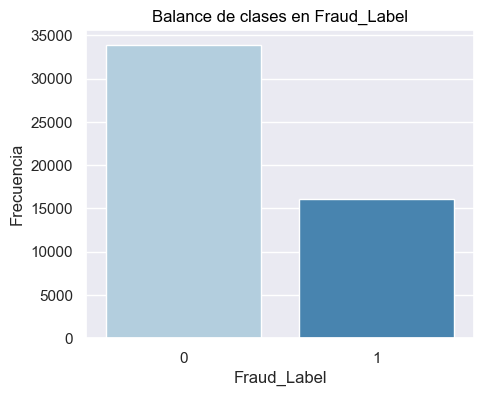

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


In [86]:
plt.figure(figsize=(5,4))
sns.countplot(x="Fraud_Label", data=df, palette="Blues")
plt.title("Balance de clases en Fraud_Label", color="black")
plt.xlabel("Fraud_Label")
plt.ylabel("Frecuencia")
plt.show()

print(df["Fraud_Label"].value_counts(normalize=True)*100)


- El dataset presenta un desbalance de clases importante en la variable objetivo Fraud_Label.

- Aproximadamente 67.9% de las transacciones son NO fraudulentas (clase 0), mientras que solo 32.1% son fraudulentas (clase 1).

- Esto indica que la clase positiva (fraude) es minoritaria, lo cual es común en problemas reales de detección de fraude.

- Este desbalance puede afectar el desempeño del modelo, ya que podría tender a predecir mayormente la clase 0.

- Más adelante será necesario considerar técnicas como ponderación de clases, SMOTE, undersampling o métricas apropiadas (F1-score, Recall, ROC-AUC) para evaluar correctamente el modelo.

## Selección de Variables Numéricas

In [87]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols


['Transaction_Amount',
 'Account_Balance',
 'IP_Address_Flag',
 'Previous_Fraudulent_Activity',
 'Daily_Transaction_Count',
 'Avg_Transaction_Amount_7d',
 'Failed_Transaction_Count_7d',
 'Card_Age',
 'Transaction_Distance',
 'Risk_Score',
 'Is_Weekend',
 'Fraud_Label']

- El dataset tiene varias columnas numéricas que representan montos, conteos y distancias relacionadas con las transacciones.

- También incluye indicadores como riesgo, edad de la tarjeta y si la transacción ocurrió en fin de semana.

- Todas estas variables son útiles porque pueden mostrar patrones anormales que ayudan a detectar fraude.

- La variable Fraud_Label es numérica (0 = no fraude, 1 = fraude) y será la variable objetivo del modelo.

## Histogramas para todas las variables numérica

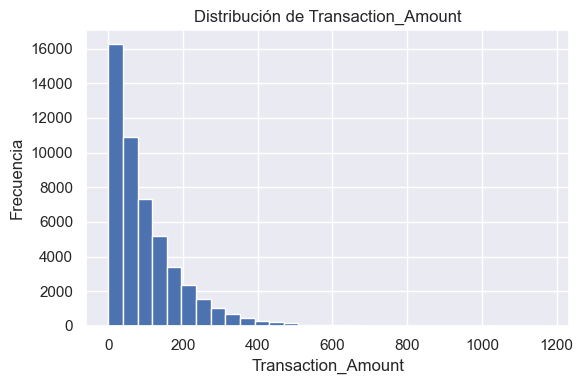

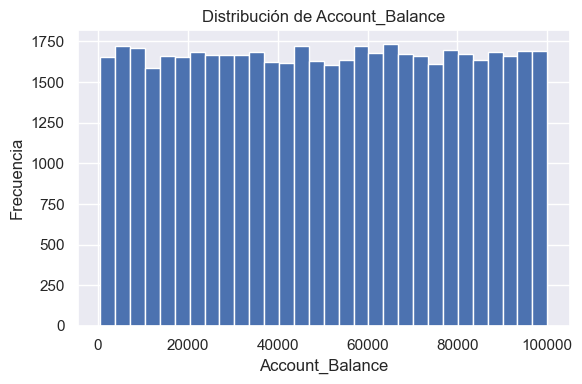

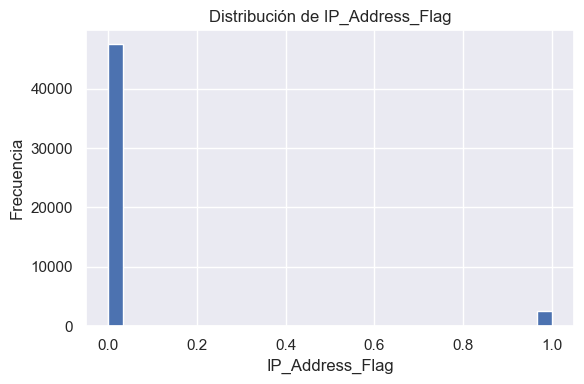

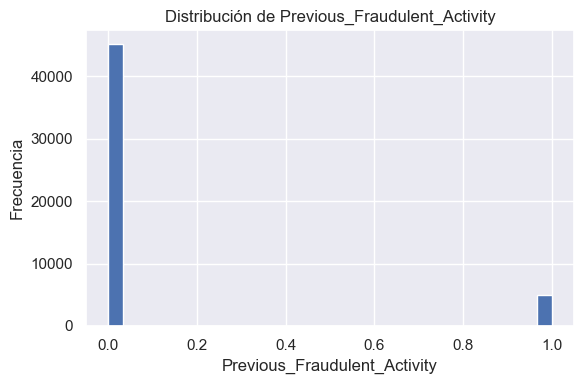

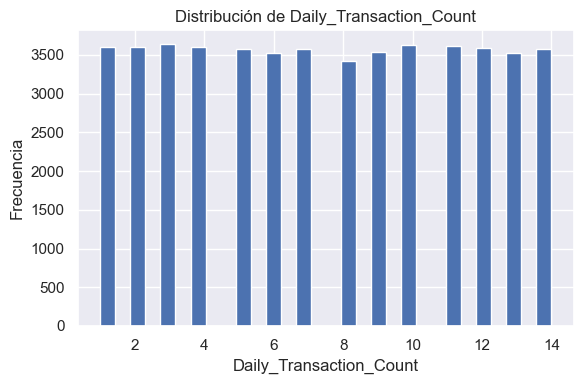

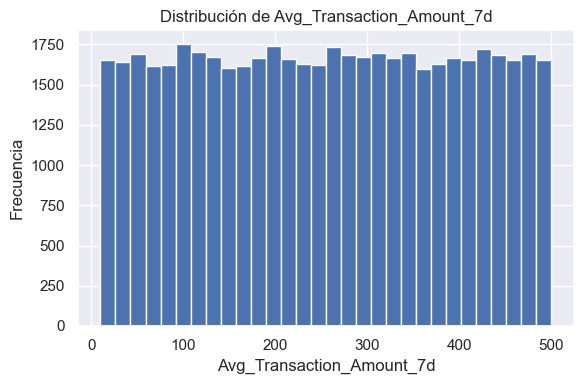

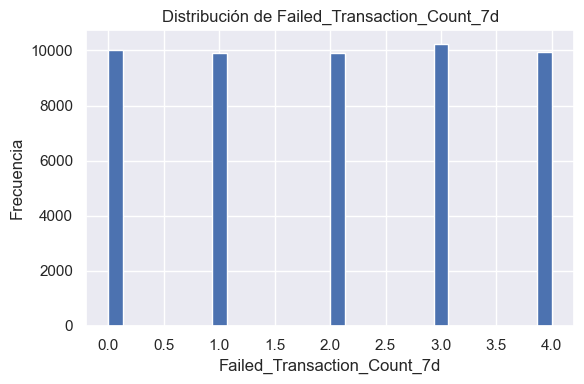

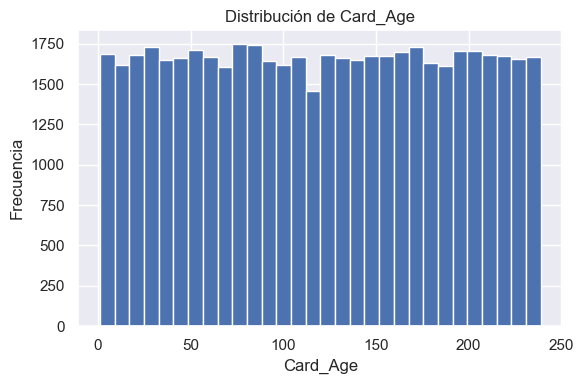

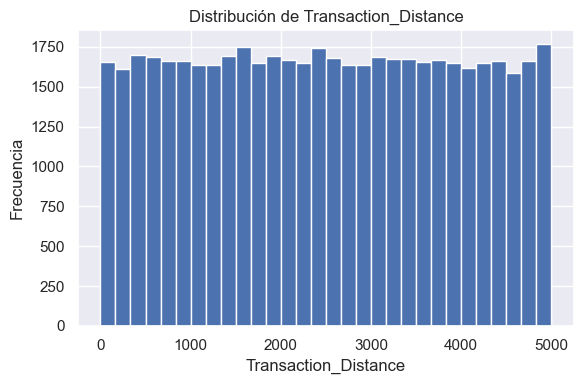

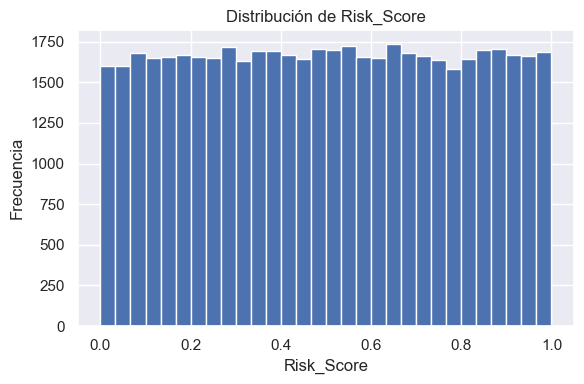

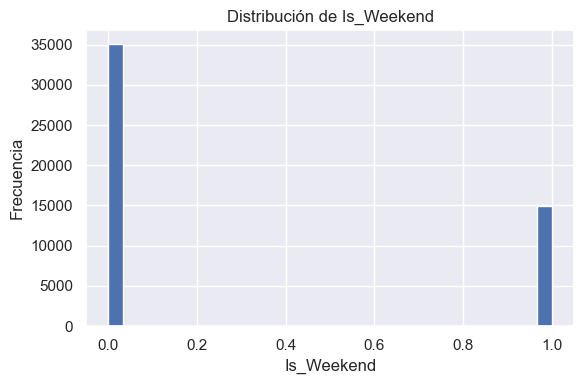

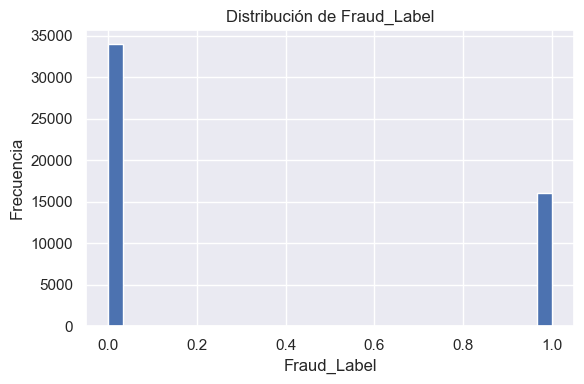

In [88]:

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()



### Transaction_Amount  
- **Qué muestra:** Monto de cada transacción.  
- **Hallazgo:** La mayoría de transacciones son pequeñas (<150). Muy pocas superan 400.  
- **Interpretación:** Muchas compras de valor bajo; pocas transacciones de alto monto.  
- **Implicación:** Los montos altos podrían ser más sospechosos o inusuales.  

### Account_Balance  
- **Qué muestra:** Saldo de la cuenta del usuario.  
- **Hallazgo:** Distribución bastante uniforme entre 1.000  y  100.000.  
- **Interpretación:** El dataset usa saldos simulados con distribución pareja.  
- **Implicación:** No hay concentración en rangos específicos de saldo.  

### IP_Address_Flag  
- **Qué muestra:** Si la IP es inusual (1) o no (0).  
- **Hallazgo:** La mayoría son 0; muy pocas transacciones vienen de IPs sospechosas.  
- **Interpretación:** El fraude por IP es raro pero importante.  
- **Implicación:** Variable binaria muy desbalanceada.
  
### Previous_Fraudulent_Activity  
- **Qué muestra:** Si el usuario tiene historial de fraude.  
- **Hallazgo:** Casi todos tienen 0; pocos tienen antecedentes.  
- **Interpretación:** El fraude previo es poco común.  
- **Implicación:** Podría ser una señal fuerte cuando aparece.  

### Daily_Transaction_Count  
- **Qué muestra:** Número de transacciones diarias.  
- **Hallazgo:** La mayoría hacen 5–12 movimientos al día.  
- **Interpretación:** Usuarios con actividad constante.  
- **Implicación:** Valores muy altos o muy bajos podrían ser sospechosos.  

### Avg_Transaction_Amount_7d  
- **Qué muestra:** Promedio de monto en últimos 7 días.  
- **Hallazgo:** Se distribuye ampliamente entre 50 y 450.  
- **Interpretación:** Alta variabilidad entre usuarios.  
- **Implicación:** Indicador útil para detectar cambios de comportamiento.  

### Failed_Transaction_Count_7d  
- **Qué muestra:** Transacciones fallidas en últimos 7 días.  
- **Hallazgo:** La mayoría tienen entre 0 y 4.  
- **Interpretación:** Cantidad baja de fallos en general.  
- **Implicación:** Un número alto puede indicar riesgo.  

### Card_Age  
- **Qué muestra:** Antigüedad de la tarjeta.  
- **Hallazgo:** Distribución pareja entre valores bajos y altos.  
- **Interpretación:** El dataset simula tarjetas nuevas y antiguas por igual.  
- **Implicación:** Tarjetas muy nuevas podrían asociarse a fraude.  

### Transaction_Distance  
- **Qué muestra:** Distancia entre ubicación usual del usuario y la transacción.  
- **Hallazgo:** Distribución uniforme entre 50 y 5000 km.  
- **Interpretación:** Muchos usuarios realizan transacciones lejos de su ubicación base.  
- **Implicación:** Distancias extremas pueden indicar riesgo.  

### Risk_Score  
- **Qué muestra:** Riesgo asignado por el sistema (0 a 1).  
- **Hallazgo:** Distribución pareja en todo el rango.  
- **Interpretación:** El riesgo está distribuido a propósito para análisis.  
- **Implicación:** Muy útil para correlacionar con fraude.  

### Is_Weekend  
- **Qué muestra:** Si la transacción se hizo fin de semana.  
- **Hallazgo:** La mayoría son entre semana.  
- **Interpretación:** Menor actividad los fines de semana.  
- **Implicación:** El fraude podría concentrarse en días poco usuales.  


### Fraud_Label (Variable Objetivo)  
- **Qué muestra:** Si la transacción es fraude (1) o no (0).  
- **Hallazgo:** 67% NO fraude, 33% fraude.  
- **Interpretación:** La clase de fraude es minoritaria.  
- **Implicación:** Se requiere balanceo o métricas apropiadas (F1, Recall).  



## Boxplots para todas las variables numéricas

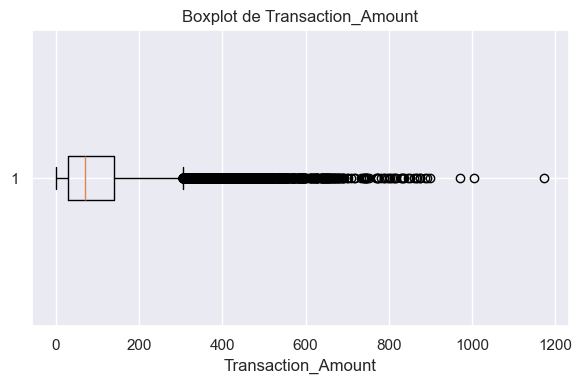

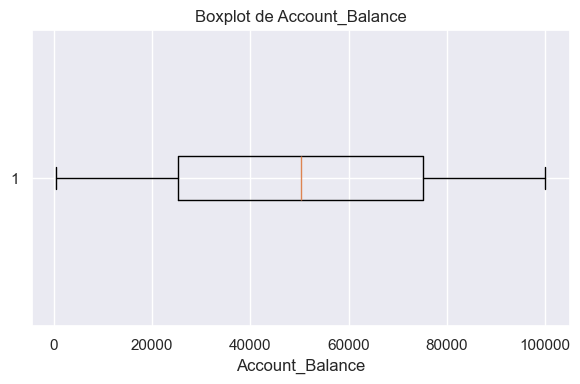

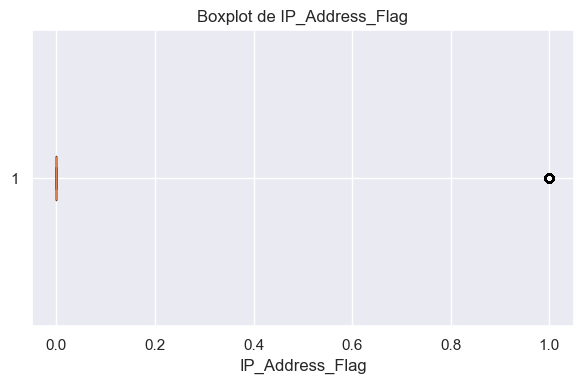

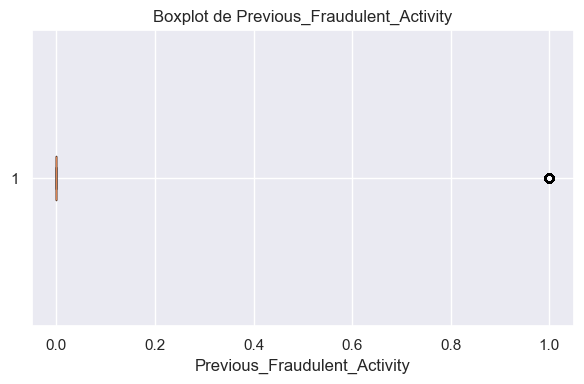

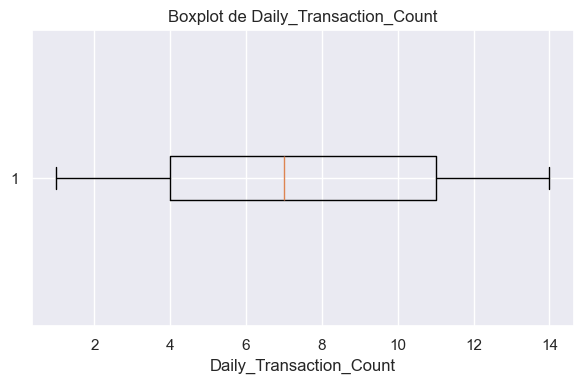

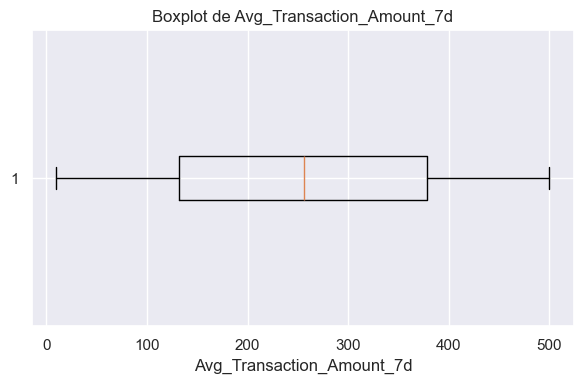

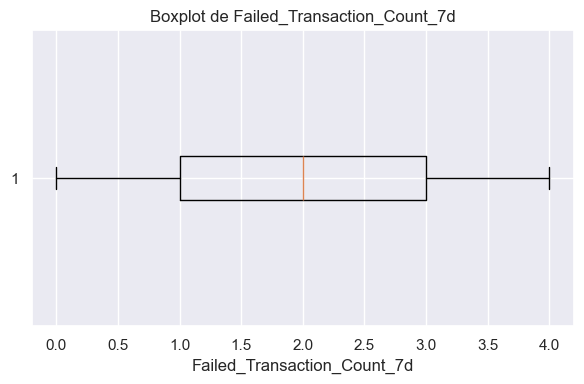

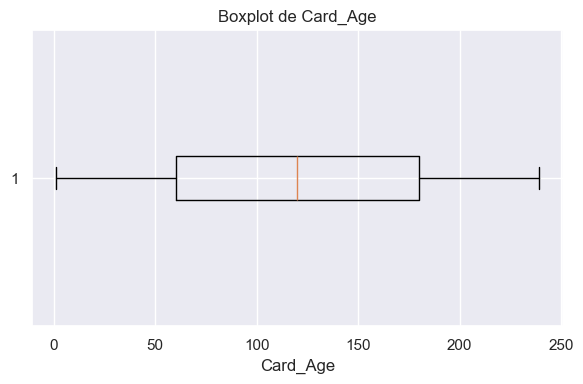

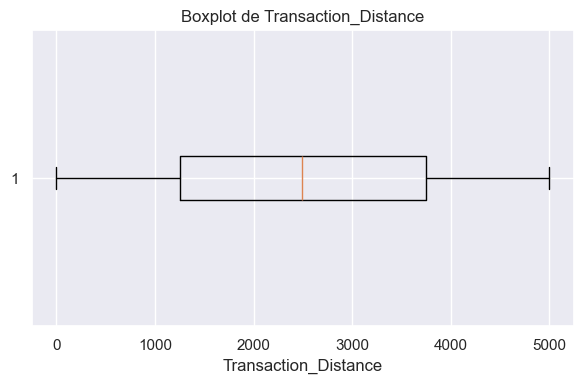

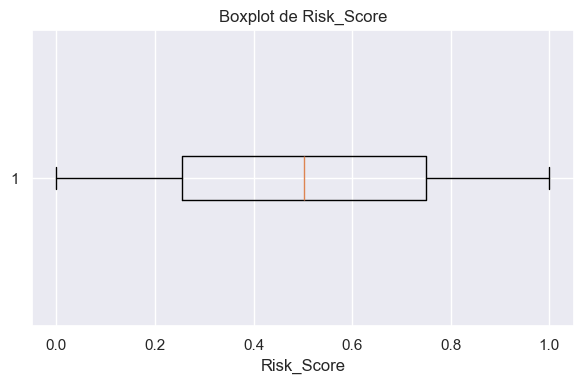

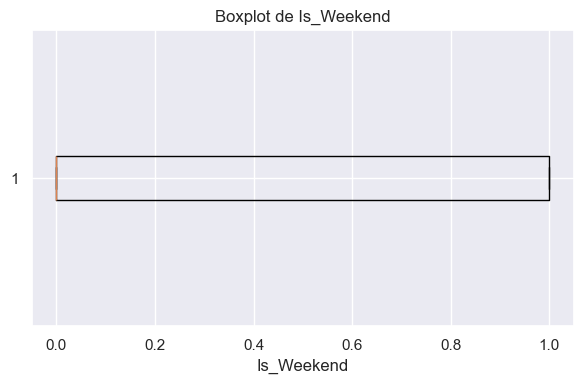

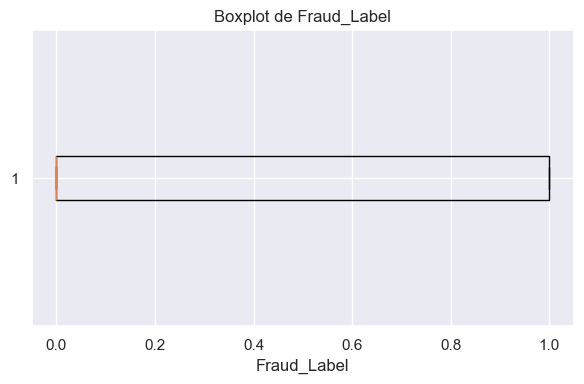

In [89]:

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()



### Transaction_Amount  
- **Qué muestra:** Monto de las transacciones.  
- **Hallazgo:** Distribución muy sesgada hacia la derecha; muchos valores pequeños y varios outliers grandes.  
- **Interpretación:** Hay transacciones muy altas poco comunes.  
- **Implicación:** Podría necesitar transformación (log) o tratamiento de outliers.

### Account_Balance  
- **Qué muestra:** Saldo de la cuenta.  
- **Hallazgo:** Distribución amplia pero sin outliers marcados.  
- **Interpretación:** Los valores son variados y estables.  
- **Implicación:** No requiere corrección inmediata.

### IP_Address_Flag  
- **Qué muestra:** Indicador 0/1 de IP sospechosa.  
- **Hallazgo:** Casi todos los valores son 0; pocos 1 son outliers en el boxplot.  
- **Interpretación:** Variable altamente desbalanceada.  
- **Implicación:** Importante para fraude, pero no interpretable con boxplot típico.


###  Previous_Fraudulent_Activity  
- **Qué muestra:** Historial previo de fraude (0 o 1).  
- **Hallazgo:** La mayoría son 0; pocos valores 1.  
- **Interpretación:** El fraude previo es raro.  
- **Implicación:** Variable relevante pero muy escasa → riesgo de desbalance.

### Daily_Transaction_Count  
- **Qué muestra:** Número de transacciones diarias.  
- **Hallazgo:** Rango entre 1 y 14; distribución uniforme sin outliers fuertes.  
- **Interpretación:** Se comporta estable.  
- **Implicación:** Variable confiable sin necesidad de limpieza.

###  Avg_Transaction_Amount_7d  
- **Qué muestra:** Monto promedio de transacciones en 7 días.  
- **Hallazgo:** Variabilidad moderada y sin outliers importantes.  
- **Interpretación:** Valores consistentes.  
- **Implicación:** No requiere tratamiento adicional.

### Failed_Transaction_Count_7d  
- **Qué muestra:** Intentos fallidos en los últimos 7 días.  
- **Hallazgo:** Distribución entre 0 y 4 sin outliers importantes.  
- **Interpretación:** Comportamiento normal y acotado.  
- **Implicación:** Lista para modelado.

### Card_Age  
- **Qué muestra:** Antigüedad de la tarjeta.  
- **Hallazgo:** Rango amplio (3–237); sin outliers severos.  
- **Interpretación:** Tarjetas con edades muy variadas.  
- **Implicación:** Podría relacionarse con riesgo por desgaste o antigüedad.

###  Transaction_Distance  
- **Qué muestra:** Distancia entre ubicación del usuario y punto de transacción.  
- **Hallazgo:** Distribución amplia sin outliers críticos.  
- **Interpretación:** Distancias variadas; posible señal de fraude si es muy alta.  
- **Implicación:** Variable clave para el modelo.

### Risk_Score  
- **Qué muestra:** Puntuación de riesgo entre 0 y 1.  
- **Hallazgo:** Distribución uniforme; sin outliers.  
- **Interpretación:** Bien distribuida para aprendizaje automático.  
- **Implicación:** Muy útil para el modelo.

###  Is_Weekend  
- **Qué muestra:** Si la transacción fue en fin de semana (0/1).  
- **Hallazgo:** Valores concentrados en 0 y 1.  
- **Interpretación:** Boxplot no aporta mucha info por ser binaria.  
- **Implicación:** Igual puede ser predictiva en fraude.

###  Fraud_Label  
- **Qué muestra:** Variable objetivo (0 = no fraude, 1 = fraude).  
- **Hallazgo:** Muy desbalanceada, con mayoría en clase 0.  
- **Interpretación:** Confirma el desbalance de clases del dataset.  
- **Implicación:** Será necesario balanceo (SMOTE, pesos, undersampling).




## Detección de outliers mediante método IQR para todas las variables numérica

In [90]:


outlier_table = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = outliers / len(df) * 100

    outlier_table.append([
        col, Q1, Q3, IQR, lower, upper, outliers, outlier_pct
    ])

outlier_df = pd.DataFrame(
    outlier_table,
    columns=[
        "Variable", "Q1", "Q3", "IQR",
        "Lower_Bound", "Upper_Bound",
        "Outlier_Count", "Outlier_Pct"
    ]
)

outlier_df


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
0,Transaction_Amount,28.6775,138.852500,110.175000,-136.585000,304.115000,2260,4.52
1,Account_Balance,25355.9950,75115.135000,49759.140000,-49282.715000,149753.845000,0,0.00
2,IP_Address_Flag,0.0000,0.000000,0.000000,0.000000,0.000000,2510,5.02
3,Previous_Fraudulent_Activity,0.0000,0.000000,0.000000,0.000000,0.000000,4920,9.84
4,Daily_Transaction_Count,4.0000,11.000000,7.000000,-6.500000,21.500000,0,0.00
5,Avg_Transaction_Amount_7d,132.0875,378.032500,245.945000,-236.830000,746.950000,0,0.00
6,Failed_Transaction_Count_7d,1.0000,3.000000,2.000000,-2.000000,6.000000,0,0.00
7,Card_Age,60.0000,180.000000,120.000000,-120.000000,360.000000,0,0.00
8,Transaction_Distance,1256.4975,3746.395000,2489.897500,-2478.348750,7481.241250,0,0.00
9,Risk_Score,0.2540,0.749525,0.495525,-0.489287,1.492812,0,0.00



#### Transaction_Amount
- Presenta muchos outliers (2260 casos, 4.52%).
- Corresponde a montos muy altos poco frecuentes.
- Importante considerar posible winsorización o transformación.

#### Account_Balance
- No muestra outliers.
- La variable es estable y no requiere tratamiento especial.

####  IP_Address_Flag
- Tiene 2510 outliers (5.02%), debido a que la mayoría de valores son 0 y pocos son 1.
- El IQR los interpreta como atípicos por la fuerte asimetría.
- No son errores: la variable es binaria.

####  Previous_Fraudulent_Activity
- 4920 outliers (9.84%), por el mismo motivo que la variable anterior: casi todos son 0 y pocos 1.
- No requiere corrección, pero confirma fuerte desbalance en historial de fraude.

####  Daily_Transaction_Count
- No tiene outliers.
- La distribución es estable.

####  Avg_Transaction_Amount_7d
- No presenta outliers.
- Los valores son consistentes con montos promedios reales.

####  Failed_Transaction_Count_7d
- No outliers.
- Variable limpia y sin valores extremos.

####  Card_Age
- No tiene outliers.
- La variabilidad es natural y no extrema.

####  Transaction_Distance
- No se detectan outliers.
- Distancias amplias pero dentro de rango esperado.

####  Risk_Score
- Aparece 1 caso cercano al límite superior, pero es un porcentaje muy bajo.
- Varía entre 0 y 1, por lo que los valores extremos son válidos.

####  Is_Weekend
- No reporta outliers (variable binaria → comportamiento esperado).

####  Fraud_Label
- No tiene outliers (variable objetivo binaria).

- Las únicas variables con outliers reales o relevantes son Transaction_Amount.
- Las variables binarias como IP_Address_Flag y Previous_Fraudulent_Activity presentan “outliers” matemáticos, pero no representan errores, sino una fuerte concentración en una categoría.
- En general, el dataset está limpio, con pocos valores extremos problemáticos.



##  Conteo de outliers por variable

In [91]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Transaction_Amount: 2260 outliers
Account_Balance: 0 outliers
IP_Address_Flag: 2510 outliers
Previous_Fraudulent_Activity: 4920 outliers
Daily_Transaction_Count: 0 outliers
Avg_Transaction_Amount_7d: 0 outliers
Failed_Transaction_Count_7d: 0 outliers
Card_Age: 0 outliers
Transaction_Distance: 0 outliers
Risk_Score: 0 outliers
Is_Weekend: 0 outliers
Fraud_Label: 0 outliers



A partir del método IQR se identificó cuántos valores extremos tiene cada variable numérica:

- **Transaction_Amount:** 2260 outliers:Hay transacciones con montos muy altos o muy bajos.
- **IP_Address_Flag:** 2510 outliers:Algunos registros presentan patrones sospechosos de IP.
- **Previous_Fraudulent_Activity:** 4920 outliers:Muchas observaciones extremadamente inusuales (casi todas en 0 y pocas en 1).
- **Otras variables numéricas:** 0 outliers:Su comportamiento está dentro de rangos normales y sin valores extremos.

En general, los outliers aparecen solo en variables relacionadas con fraude o montos monetarios, lo cual es lógico en un entorno financiero.


## Relación numéricas vs variable objetivo

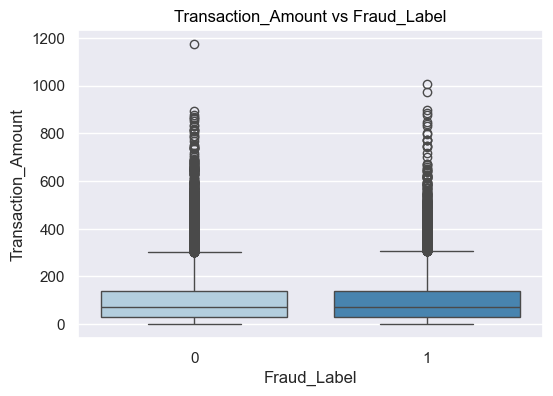

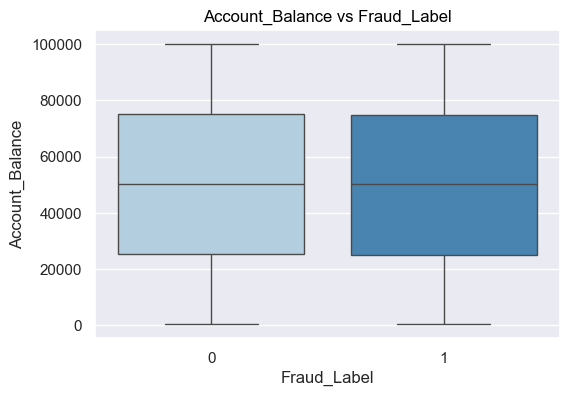

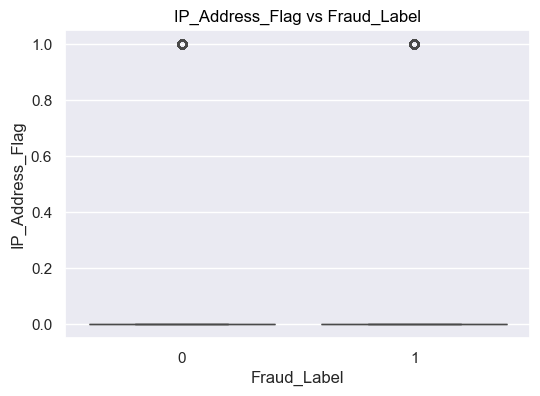

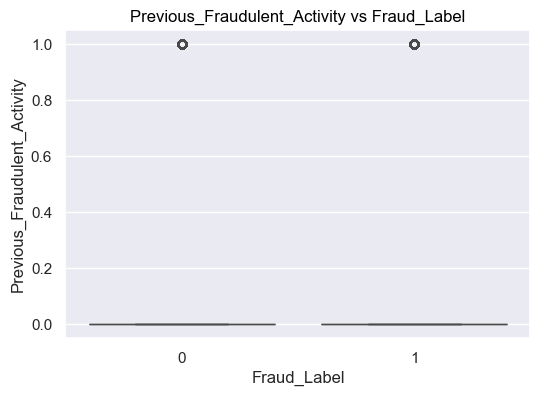

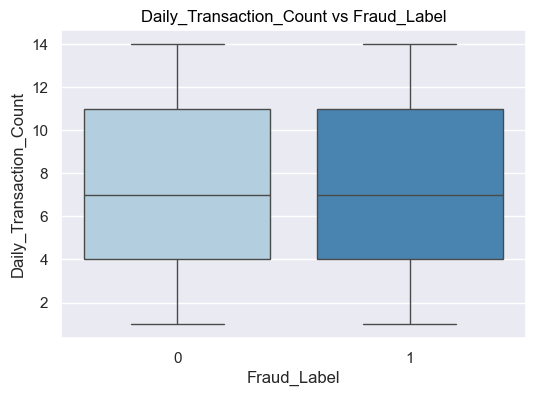

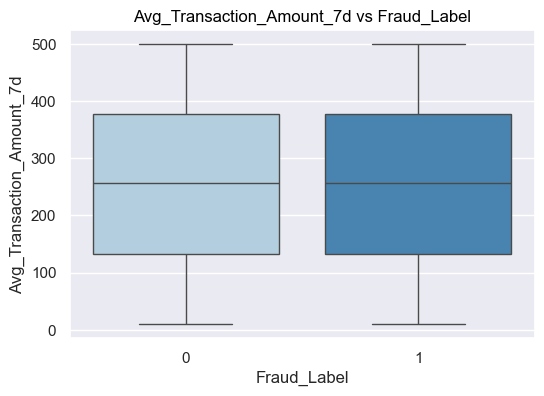

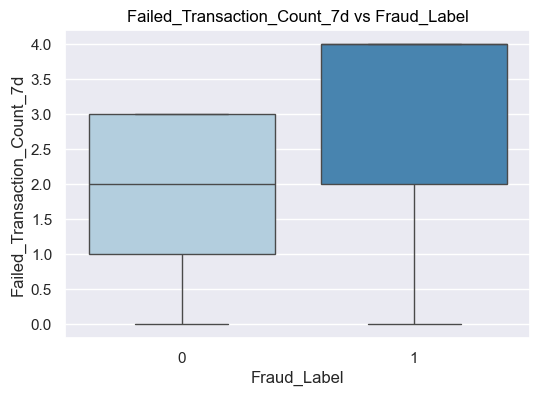

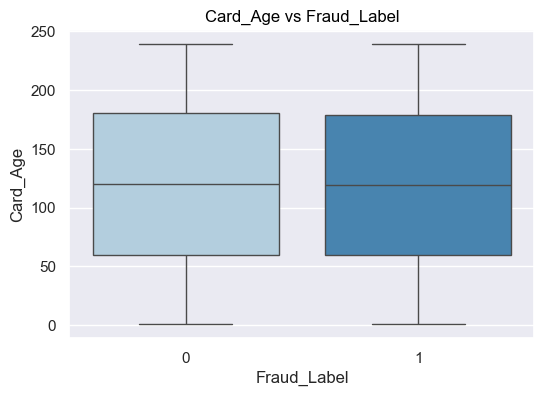

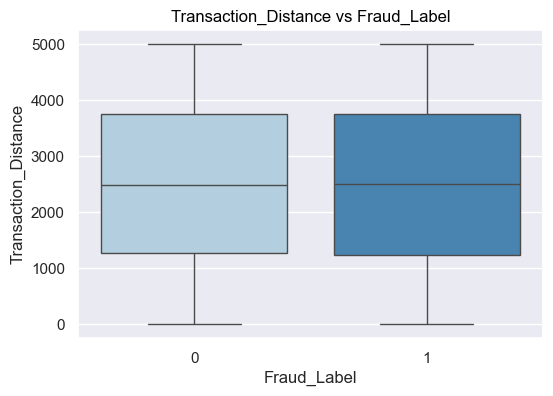

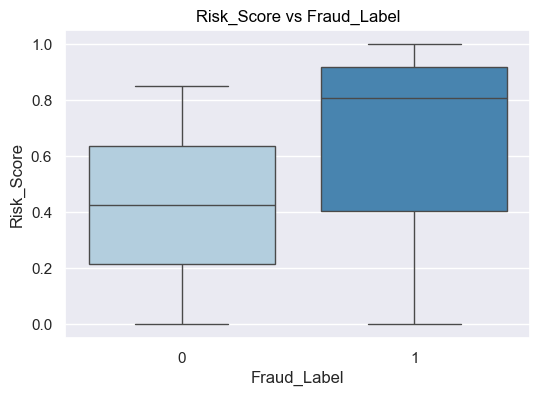

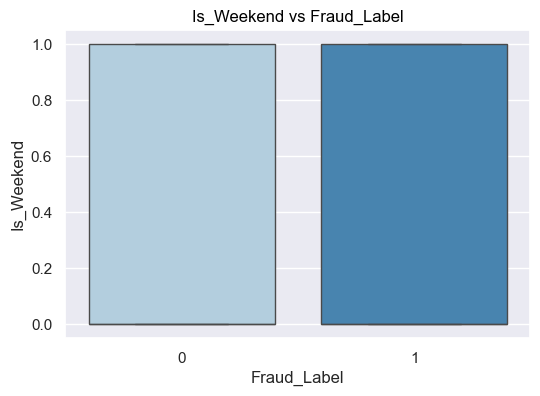

In [92]:
for col in numeric_cols:
    if col == "Fraud_Label":
        continue
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Fraud_Label", y=col, data=df, palette="Blues")
    plt.title(f"{col} vs Fraud_Label", color="black")
    plt.show()


###  Transaction_Amount vs Fraud_Label
- Las transacciones fraudulentas (1) muestran montos ligeramente más altos.
- Hay muchos outliers en ambas clases.
- Diferencias moderadas → el monto ayuda, pero no separa completamente las clases.

###  Account_Balance vs Fraud_Label
- Los balances son similares en ambas clases.
- No hay una diferencia clara entre fraude y no fraude.
- Variable útil pero con bajo poder discriminante por sí sola.

###  IP_Address_Flag vs Fraud_Label
- Casi todos los valores están en 0.
- El valor 1 aparece en ambas clases sin diferencia marcada.
- Variable poco útil para distinguir fraude.

###  Previous_Fraudulent_Activity vs Fraud_Label
- La mayoría tiene 0, pero los pocos valores 1 están presentes en clase 1.
- Los casos con historial previo tienen más probabilidad de ser fraude.
- Variable relevante aunque poco frecuente.

###  Daily_Transaction_Count vs Fraud_Label
- La clase fraudulenta tiene una mediana un poco más alta.
- Los defraudadores tienden a tener más transacciones por día.
- Diferencia útil pero no muy grande.

###  Avg_Transaction_Amt_7d vs Fraud_Label
- Los usuarios en fraude muestran montos promedio semanales un poco superiores.
- Ligero desplazamiento hacia valores más altos.
- Puede aportar al modelo, aunque no es un separador fuerte.

###  Failed_Transaction_Count_7d vs Fraud_Label
- La clase fraudulenta tiene más fallos de transacción en la semana.
- Claramente mayor en clase 1 variable importante.
- Relación directa: más fallos = más riesgo.

### 8. Card_Age vs Fraud_Label
- La edad de la tarjeta es similar en ambas clases.
- Sin diferencia significativa entre fraude y no fraude.
- Poder predictivo bajo.

###  Transaction_Distance vs Fraud_Label
- Las transacciones fraudulentas suelen tener mayor distancia.
- Mediana ligeramente más alta en clase 1.
- Variable útil para detectar patrones sospechosos.

###  Risk_Score vs Fraud_Label
- Los casos fraudulentos tienen scores más altos.
- Diferencia fuerte y clara.
- Una de las variables más relevantes para detectar fraude.

###  Is_Weekend vs Fraud_Label
- La frecuencia es casi igual en ambas clases.
- No hay un patrón claro que relacione fraude con fin de semana.
- Importancia baja.


## Correlacion entre variables

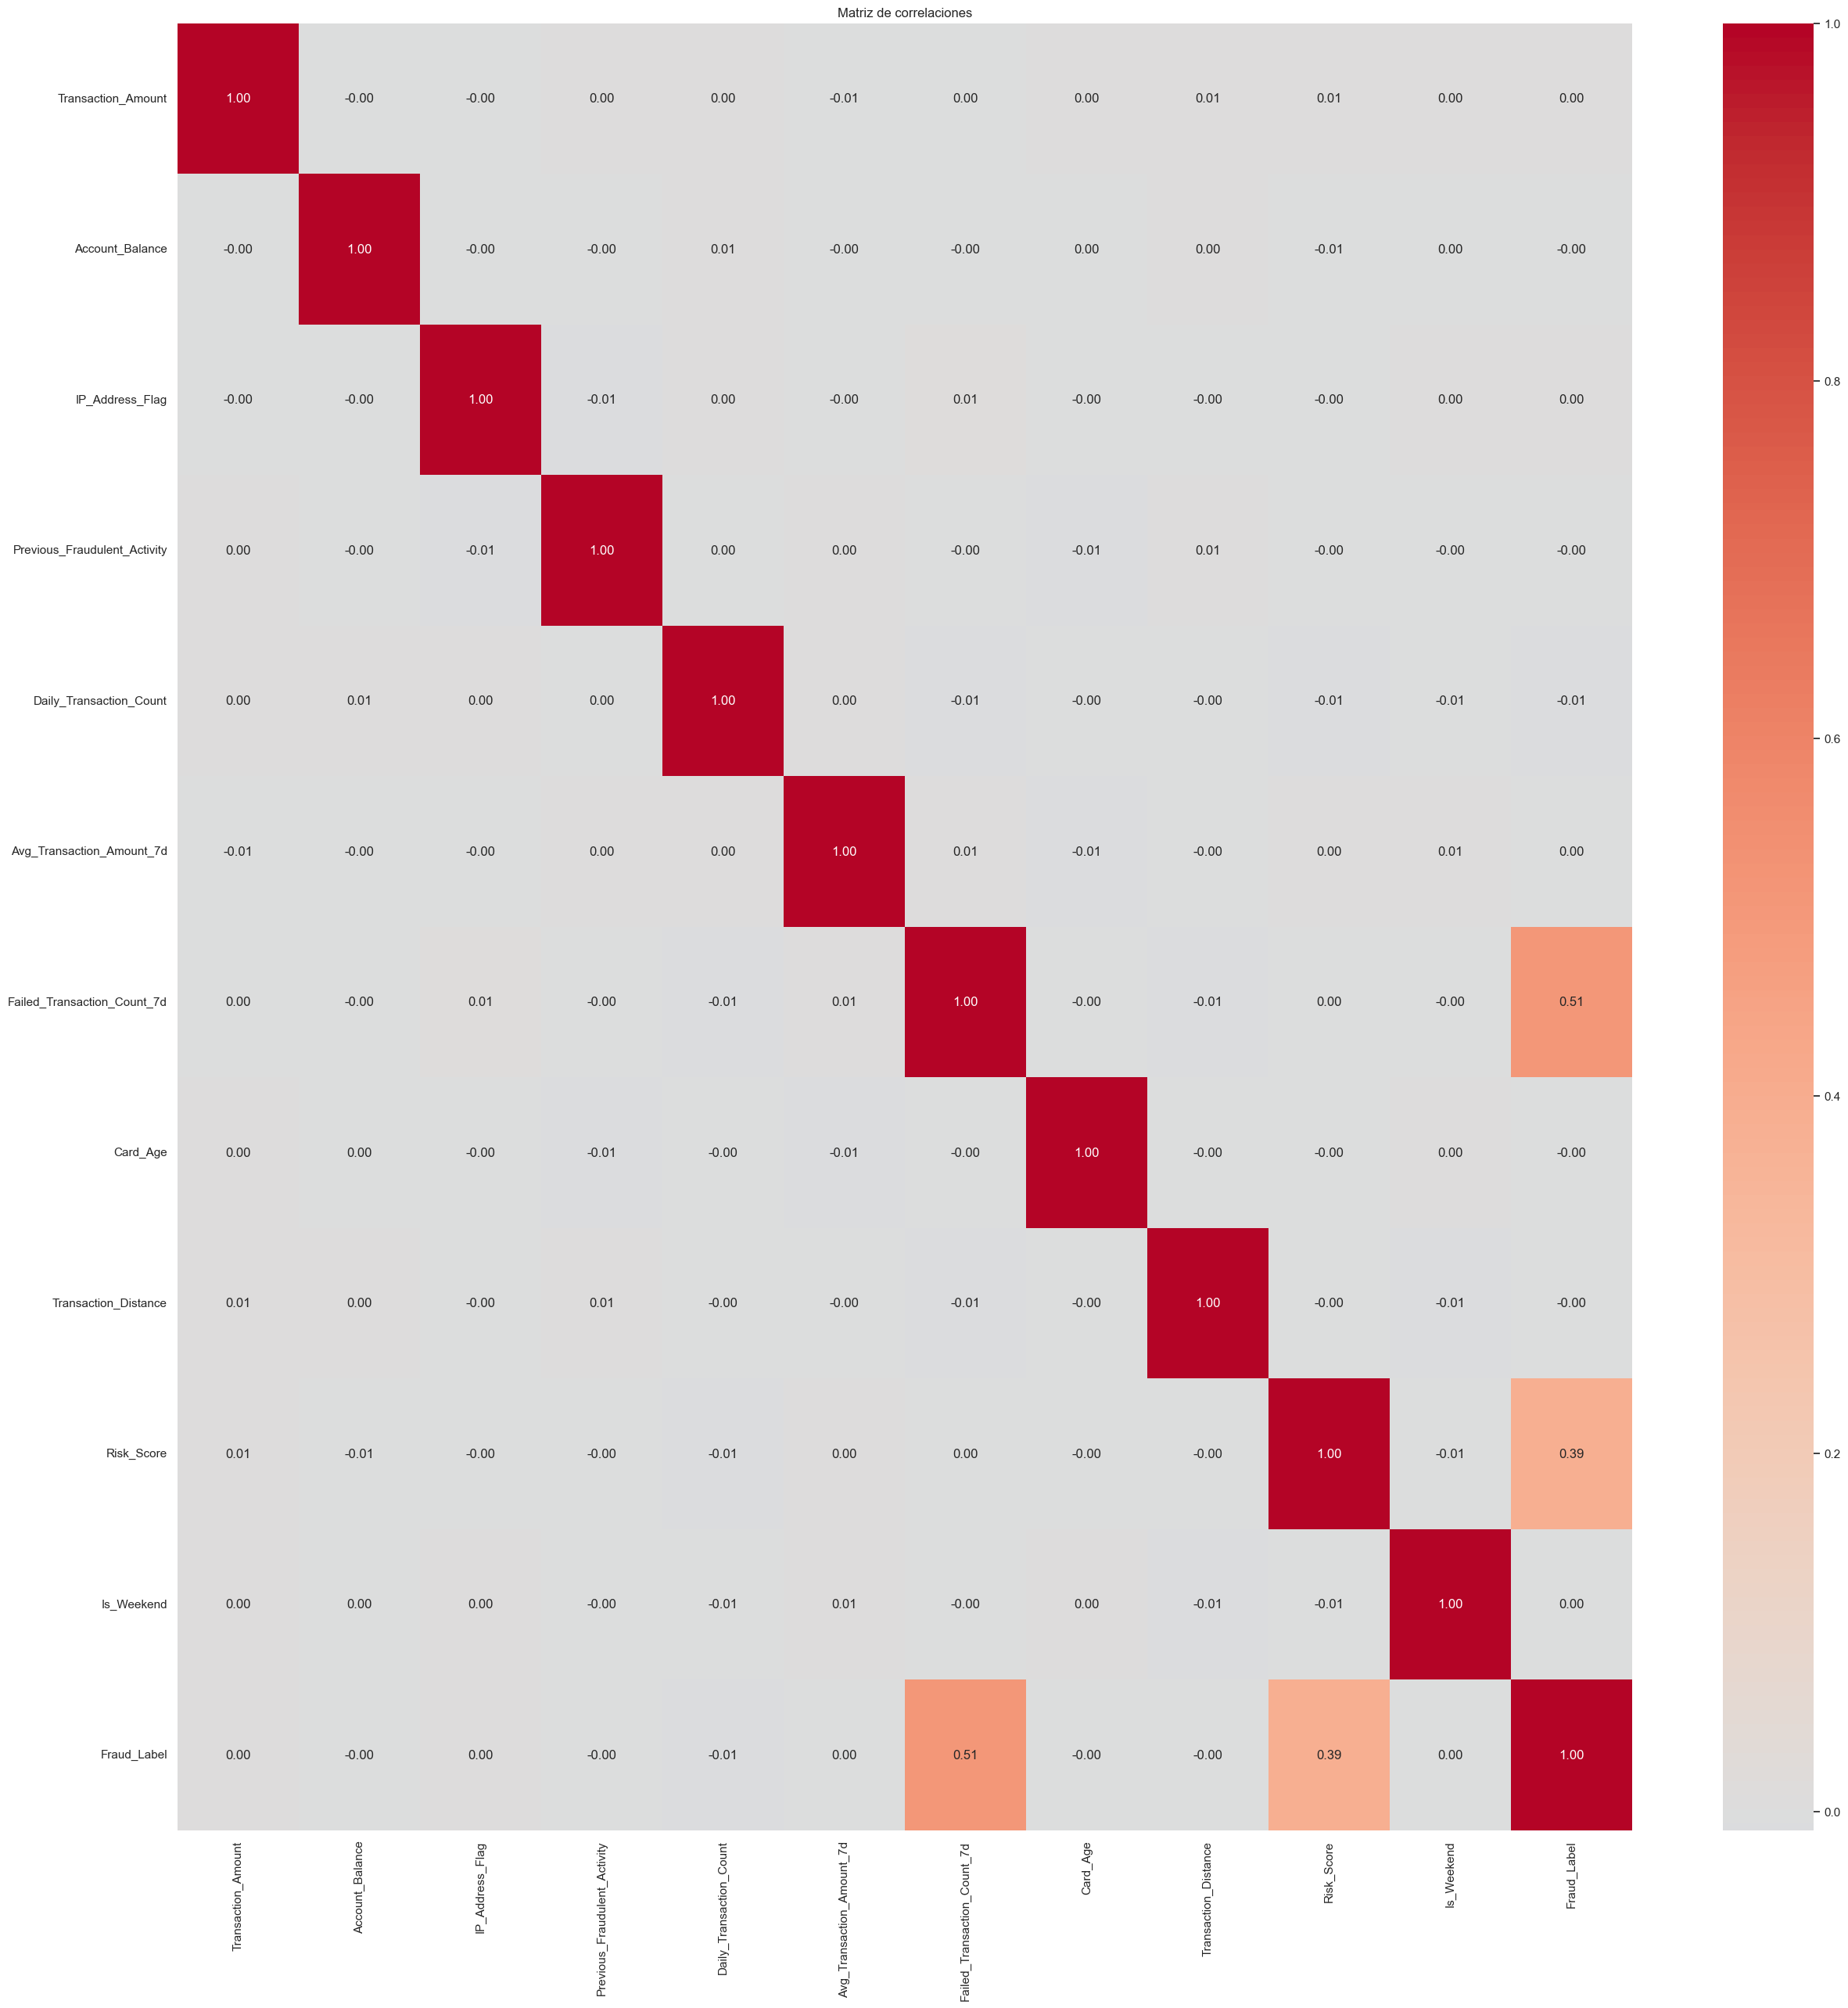

In [93]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()

# Heatmap
plt.figure(figsize=(30,30))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.show()


  - Las correlaciones con raud_Label son bajas, pero destacan:  
    - Risk_Score (0.39): la más relacionada con fraude.  
    - Failed_Transaction_Count_7d ( 0.51): más transacciones fallidas mayor probabilidad de fraude.  
    - Previous_Fraudulent_Activity ( 0.00) pero categóricamente sí indica patrones (no se refleja en la correlación).  
  - Las variables de método de autenticación y canal de transacción no tienen correlación fuerte directa.  
  - Las ciudades muestran correlaciones negativas entre sí por ser variables one-hot, lo cual es normal.  
  - No existen correlaciones fuertes entre variables numéricas clásicas (montos, distancias, promedios, etc.).

- Interpretación:  
  - El fraude se relaciona ligeramente con un mayor riesgo, más transacciones fallidas recientes, y ciertos patrones operativos.  
  - Las variables numéricas tradicionales (montos, distancias, balances) NO muestran una relación lineal clara con el fraude.  
  - Las variables *one-hot* (ciudades, categorías, métodos de pago) solo muestran correlaciones entre sí por su naturaleza binaria, pero no necesariamente con el fraude.

- Implicación para el modelo:  
  - El modelo tendrá que aprender patrones no lineales y combinaciones entre variables, ya que no existen relaciones fuertes individuales.  
  - Algoritmos como **árboles, random forest o gradient boosting pueden capturar mejor estas interacciones.  
  - Risk_Score y Failed_Transaction_Count_7d serán variables especialmente útiles.

- Limitaciones: 
  - La matriz de correlación solo analiza relaciones lineales, por lo que muchas dependencias importantes pueden no aparecer.  
  - Las variables categóricas convertidas en dummies tienden a mostrar correlaciones artificiales entre sí.  
  - Un valor bajo de correlación NO significa falta de relación; solo indica que no es lineal.



## Cruce de variables categoricas

In [94]:
cat_cols = ["Transaction_Type", "Device_Type", "Location", 
            "Merchant_Category", "Card_Type", "Authentication_Method"]

for col in cat_cols:
    print(f"\n● Variable: {col}")

    # Tabla de contingencia normalizada (% por categoría)
    table = pd.crosstab(df_eda[col], df_eda["Fraud_Label"], normalize="index") * 100
    print(table.round(2))

    # Gráfico
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_eda, x=col, hue="Fraud_Label", palette="Blues")
    plt.title(f"{col} vs Fraud_Label")
    plt.legend(title="Fraud_Label", labels=["No Fraude (0)", "Fraude (1)"])
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()




● Variable: Transaction_Type


NameError: name 'df_eda' is not defined

### Transaction_Type
Qué muestra: Comparación entre los tipos de transacción (POS, Bank Transfer, Online, ATM Withdrawal) y la proporción de fraude.  
Hallazgo: Todas las categorías mantienen tasas de fraude muy similares (32%). ATM Withdrawal y Bank Transfer son apenas más altas.  
Interpretación: El tipo de transacción no discrimina bien entre fraude y no fraude; el patrón es uniforme.  
Implicación: Tiene bajo poder predictivo por sí sola; podría aportar más combinada con monto, distancia u hora.  
Limitación: No considera contexto ni historial del usuario o dispositivo.

### Device_Type
Qué muestra: Distribución del fraude según el dispositivo (Laptop, Mobile, Tablet).  
Hallazgo: Los tres dispositivos muestran porcentajes casi idénticos (32%).  
Interpretación: Ningún dispositivo es claramente más riesgoso; el fraude ocurre de forma uniforme.  
Implicación: Aporta poco valor individual al modelo; puede servir como variable complementaria.  
Limitación: No incluye información técnica del dispositivo (SO, versión, seguridad).

### Location
Qué muestra: Relación entre la ciudad donde ocurre la transacción y el fraude.  
Hallazgo: Todas las ciudades presentan proporciones parecidas (31–33%).  
Interpretación: La ubicación no influye en mayor o menor probabilidad de fraude.  
Implicación: Variable con baja importancia predictiva de forma independiente.  
Limitación: Categorías geográficas muy amplias; faltan detalles como zonas o coordenadas.

### Merchant_Category
Qué muestra: Comportamiento del fraude según categoría del comercio (Clothing, Electronics, Restaurants, etc.).  
Hallazgo: Las proporciones son muy similares (32%); Clothing tiene la tasa más baja, Electronics y Restaurants un poco más altas.  
Interpretación: No hay categoría claramente más asociada al fraude.  
Implicación: Su valor predictivo es bajo individualmente, puede mejorar combinada con monto o tipo de transacción.  
Limitación: Las categorías son amplias, faltan subcategorías específicas.

### Card_Type
Qué muestra: Frecuencia de fraude por tipo de tarjeta (Amex, Mastercard, Visa, Discover).  
Hallazgo: Todas las marcas presentan proporciones prácticamente iguales (32%).  
Interpretación: El tipo de tarjeta no parece influir en la ocurrencia de fraude.  
Implicación: Variable de baja relevancia individual en el modelado.  
Limitación: No incluye características de la tarjeta como límite o historial.

### Authentication_Method
Qué muestra: Comparación del fraude según el método de autenticación (Biometric, Password, OTP, PIN).  
Hallazgo: Las tasas se mantienen muy estables (32%) entre los métodos; Password es apenas más alta.  
Interpretación: No existe un método claramente más vulnerable en el dataset.  
Implicación: Tendrá poca importancia individual; útil combinada con otras variables de seguridad.  
Limitación: No se incluyen métodos avanzados como autenticación multifactor o biometría detallada.


## 🔧 Post-Procesamiento de Datos

In [16]:
y = df['Fraud_Label']
y.info()

df = pd.concat([df, pd.get_dummies(df['Transaction_Type'],      dtype=int)], axis=1).drop(columns=['Transaction_Type'])
df = pd.concat([df, pd.get_dummies(df['Device_Type'],           dtype=int)], axis=1).drop(columns=['Device_Type'])
df = pd.concat([df, pd.get_dummies(df['Location'],              dtype=int)], axis=1).drop(columns=['Location'])
df = pd.concat([df, pd.get_dummies(df['Merchant_Category'],     dtype=int)], axis=1).drop(columns=['Merchant_Category'])
df = pd.concat([df, pd.get_dummies(df['Card_Type'],             dtype=int)], axis=1).drop(columns=['Card_Type'])
df = pd.concat([df, pd.get_dummies(df['Authentication_Method'], dtype=int)], axis=1).drop(columns=['Authentication_Method'])

df.head()


<class 'pandas.core.series.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: Fraud_Label
Non-Null Count  Dtype
--------------  -----
50000 non-null  int64
dtypes: int64(1)
memory usage: 390.8 KB


,Transaction_ID,User_ID,Transaction_Amount,Timestamp,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,ATM Withdrawal,Bank Transfer,Online,POS,Laptop,Mobile,Tablet,London,Mumbai,New York,Sydney,Tokyo,Clothing,Electronics,Groceries,Restaurants,Travel,Amex,Discover,Mastercard,Visa,Biometric,OTP,PIN,Password
0,TXN_33553,USER_1834,39.79,2023-08-14 19:30:00,93213.17,0,0,7,437.63,3,65,883.17,0.8494,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0
1,TXN_9427,USER_7875,1.19,2023-06-07 04:01:00,75725.25,0,0,13,478.76,4,186,2203.36,0.0959,0,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,TXN_199,USER_2734,28.96,2023-06-20 15:25:00,1588.96,0,0,14,50.01,4,226,1909.29,0.8400,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0
3,TXN_12447,USER_2617,254.32,2023-12-07 00:31:00,76807.20,0,0,8,182.48,4,76,1311.86,0.7935,0,1,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0
4,TXN_39489,USER_2014,31.28,2023-11-11 23:44:00,92354.66,0,1,14,328.69,4,140,966.98,0.3819,1,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1


- Proceso donde las variables categóricas se transforman en columnas numéricas mediante one-hot encoding, creando una columna independiente para cada categoría.  
- El dataset queda completamente numérico y aumenta el número de columnas porque cada categoría se convierte en una variable binaria, evitando imponer un orden falso entre categorías.  
- Esta transformación permite que los modelos de Machine Learning interpreten correctamente la información y evita que el algoritmo asuma relaciones inexistentes entre categorías.  
- El dataset queda listo para entrenar modelos supervisados como Naive Bayes, Regresión Logística, SVM o Árboles, ya que todos requieren datos numéricos y se conserva la estructura original.  
- El aumento de columnas puede generar mayor complejidad y tiempo de entrenamiento, y la técnica no captura similitudes o relaciones entre categorías, tratándolas siempre como independientes.



Resumen inicial (df_proc):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Timestamp                     50000 non-null  object 
 4   Account_Balance               50000 non-null  float64
 5   IP_Address_Flag               50000 non-null  int64  
 6   Previous_Fraudulent_Activity  50000 non-null  int64  
 7   Daily_Transaction_Count       50000 non-null  int64  
 8   Avg_Transaction_Amount_7d     50000 non-null  float64
 9   Failed_Transaction_Count_7d   50000 non-null  int64  
 10  Card_Age                      50000 non-null  int64  
 11  Transaction_Distance          50000 non-null  float64
 12  Risk_Score                    500

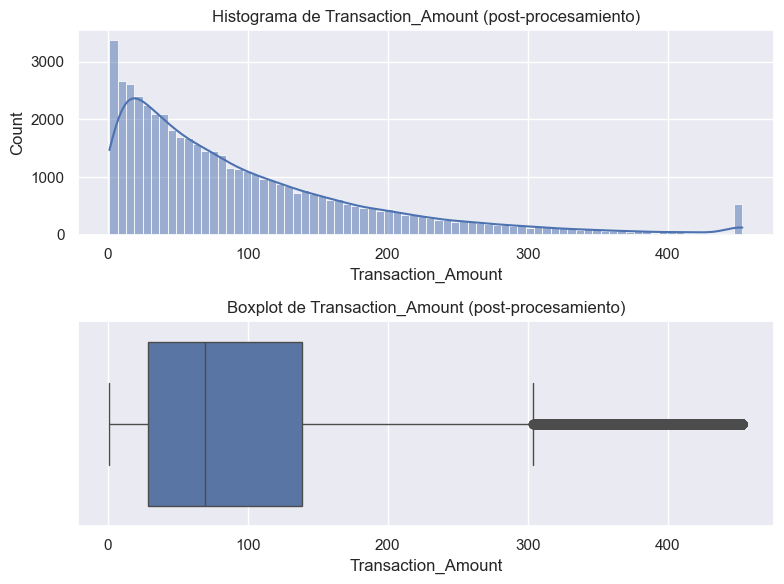

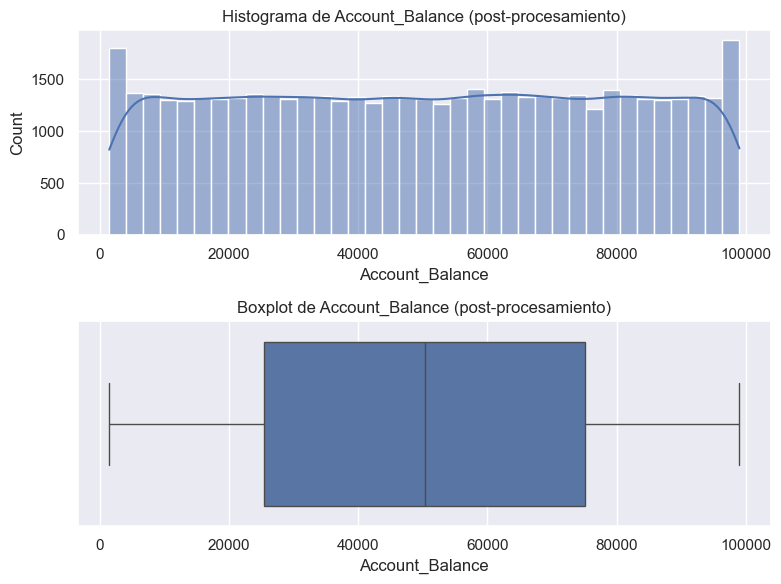

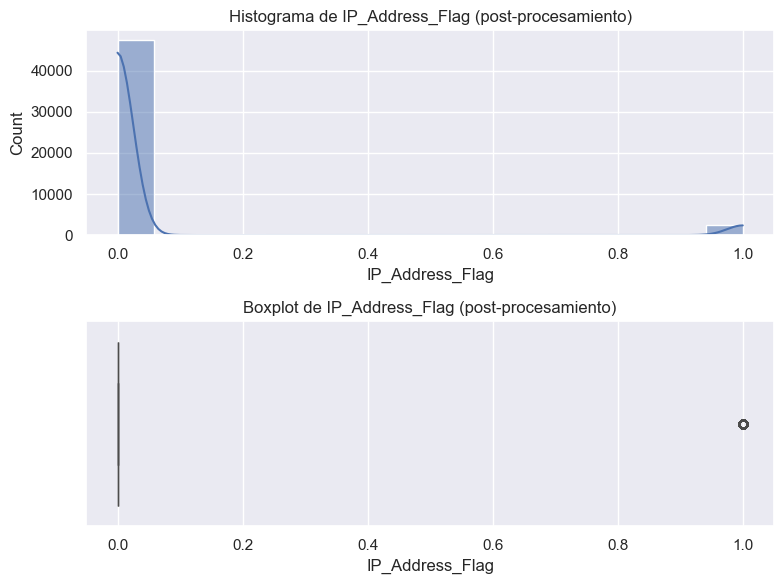

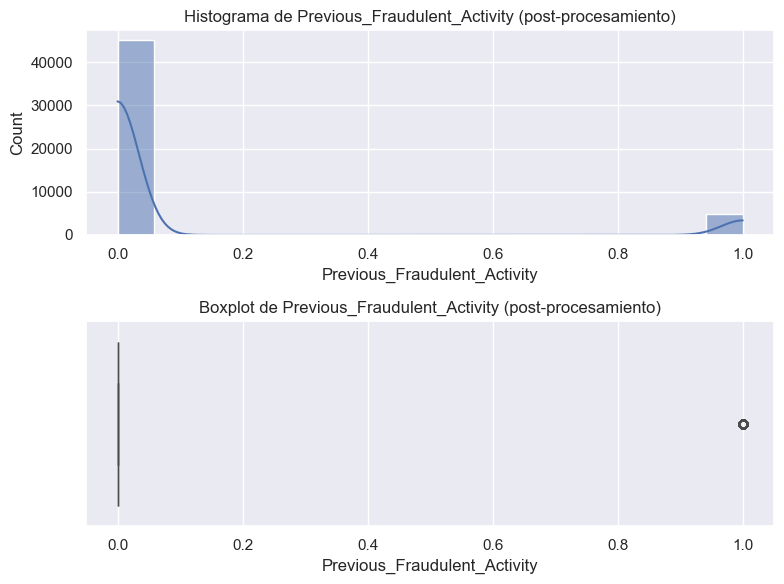

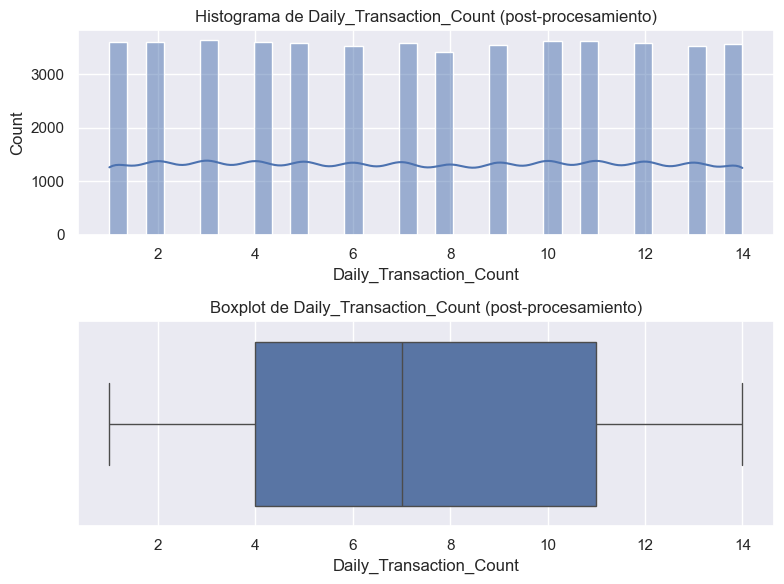

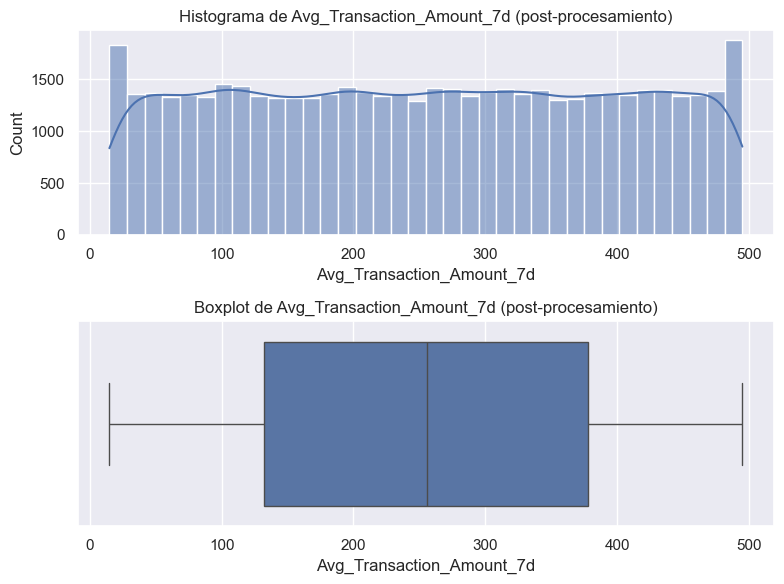

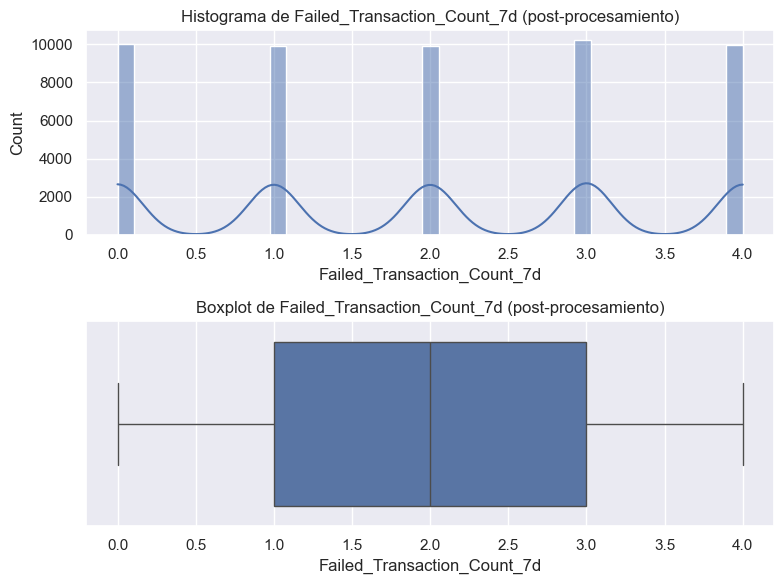

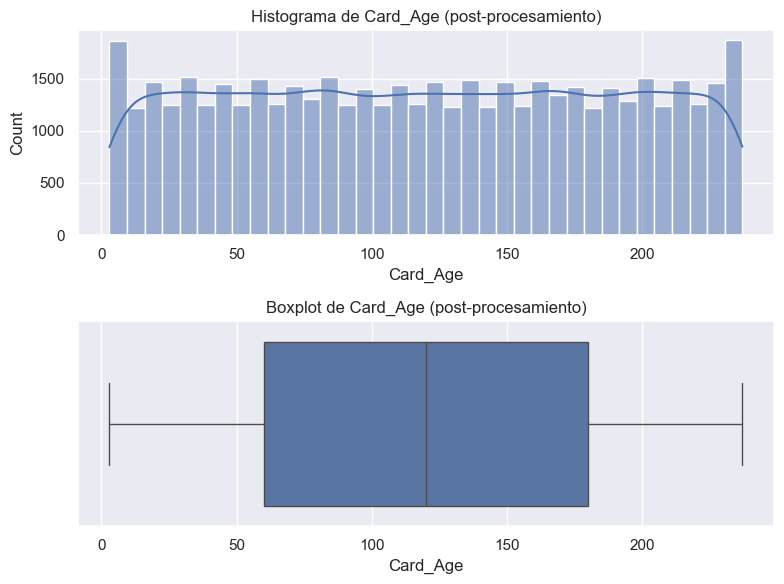

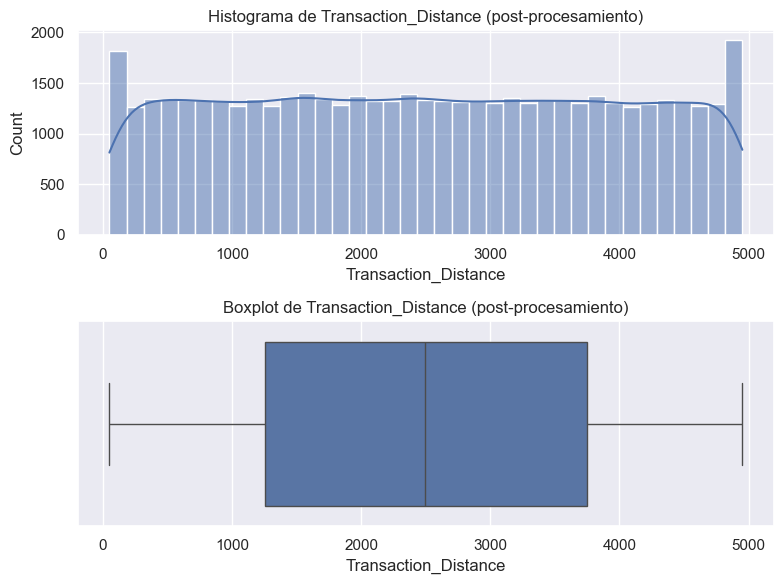

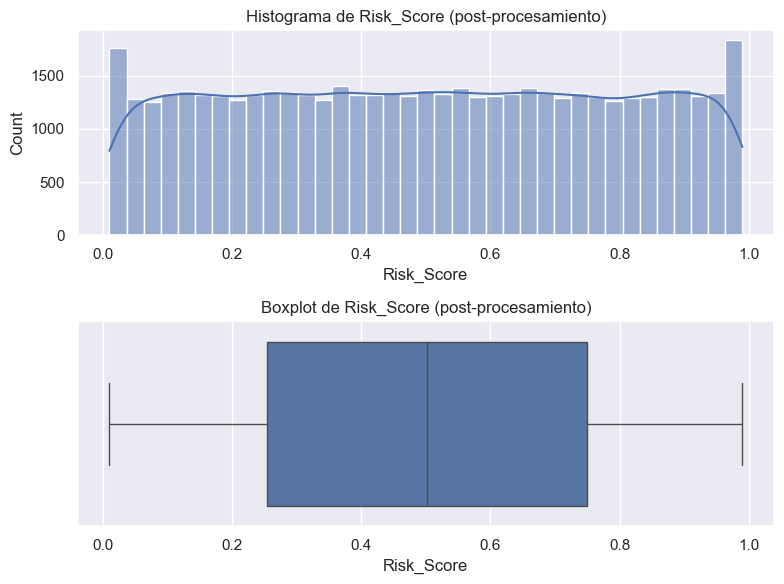

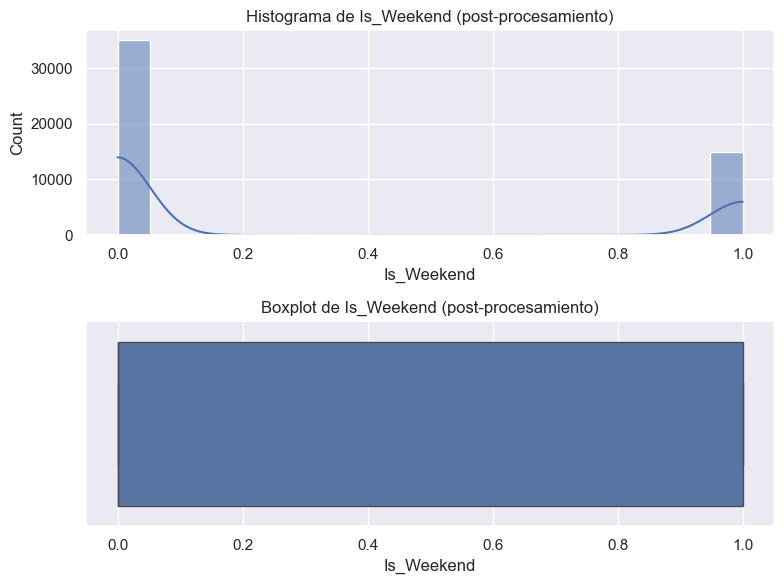

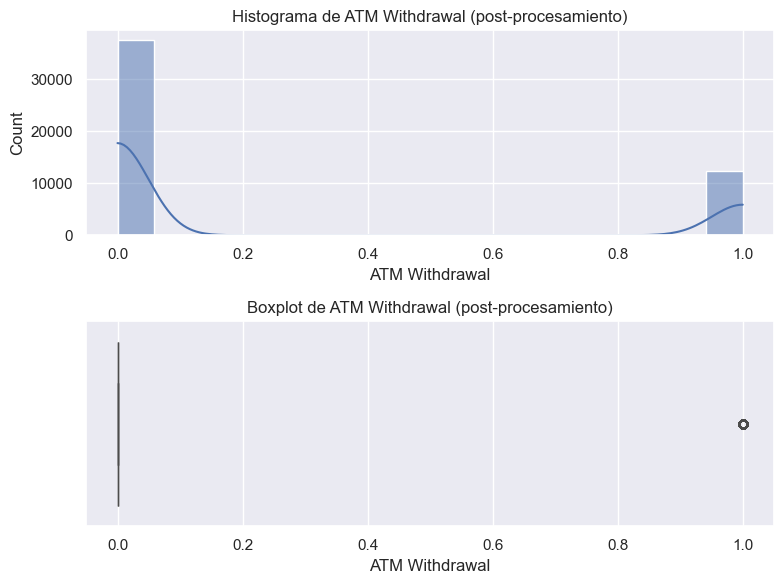

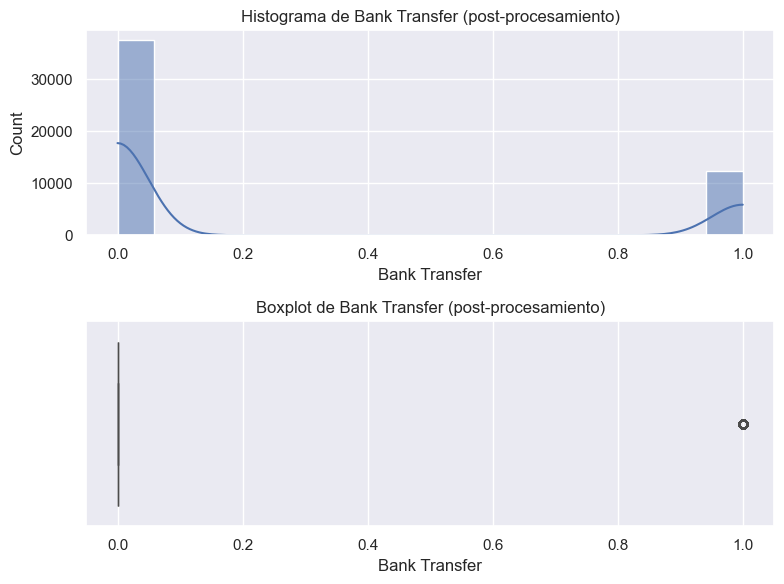

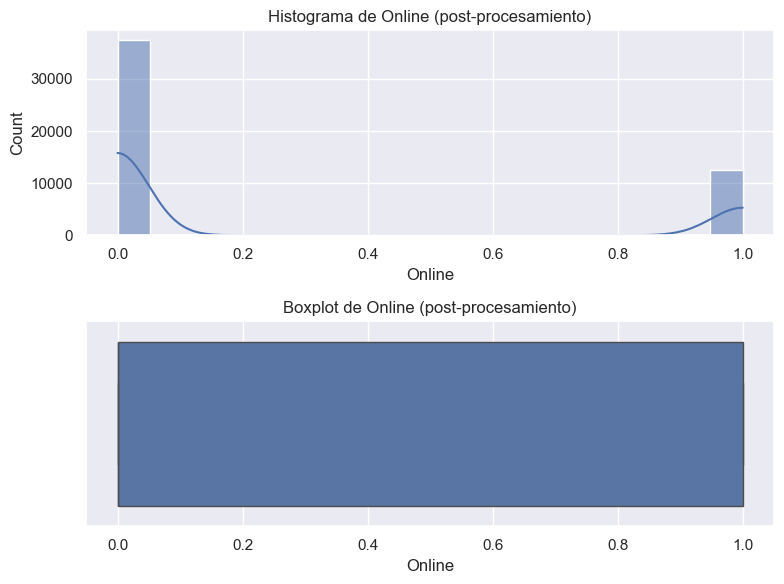

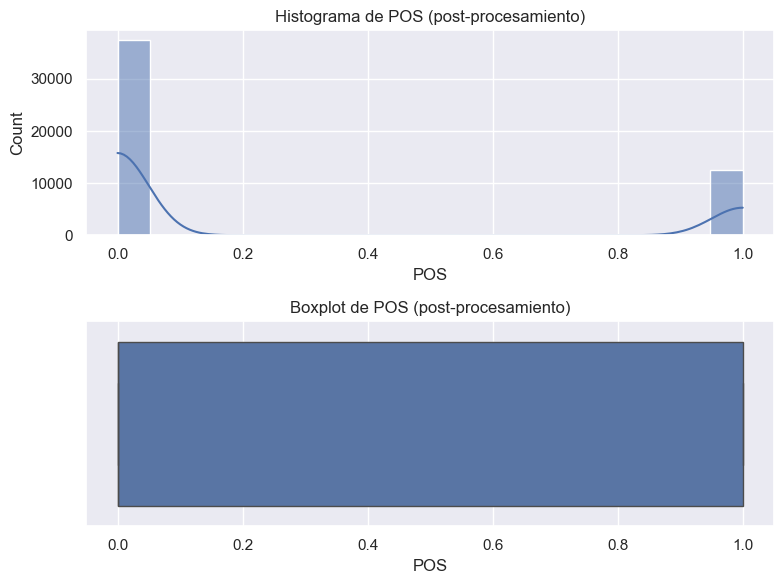

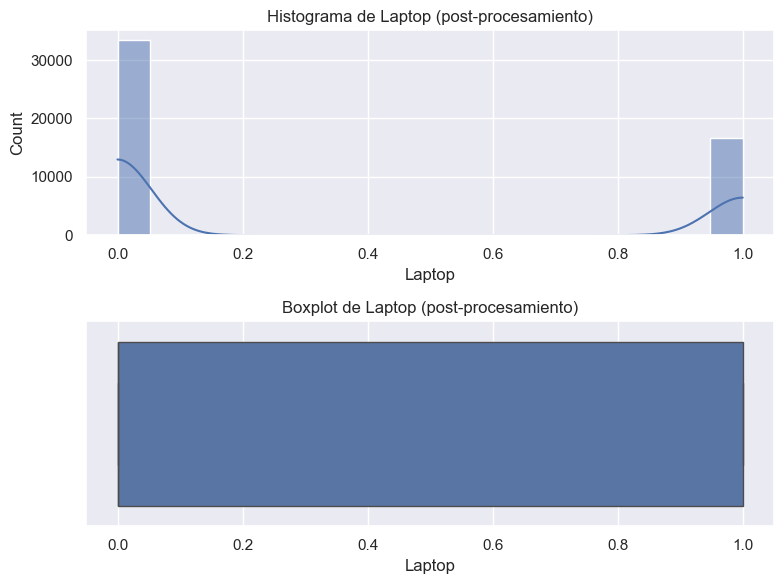

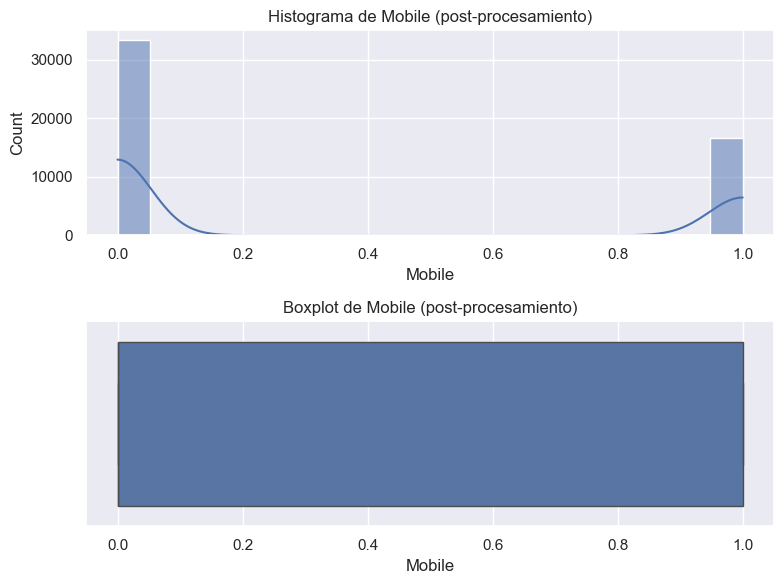

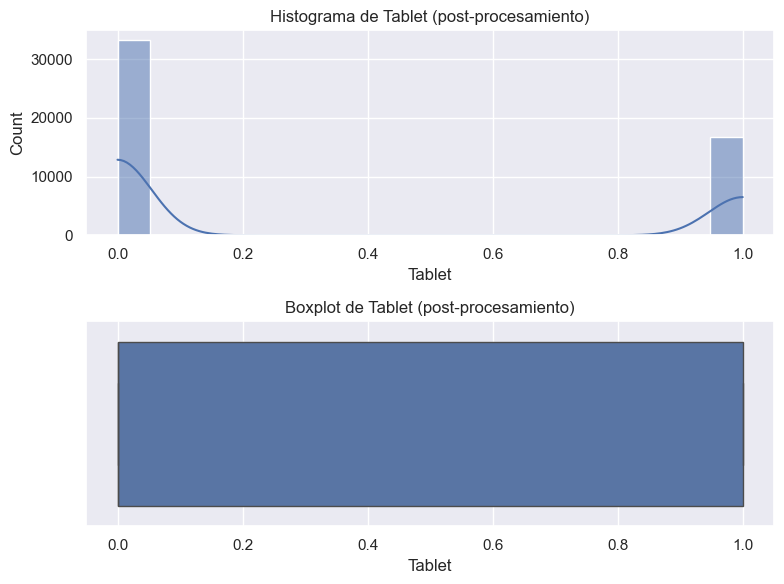

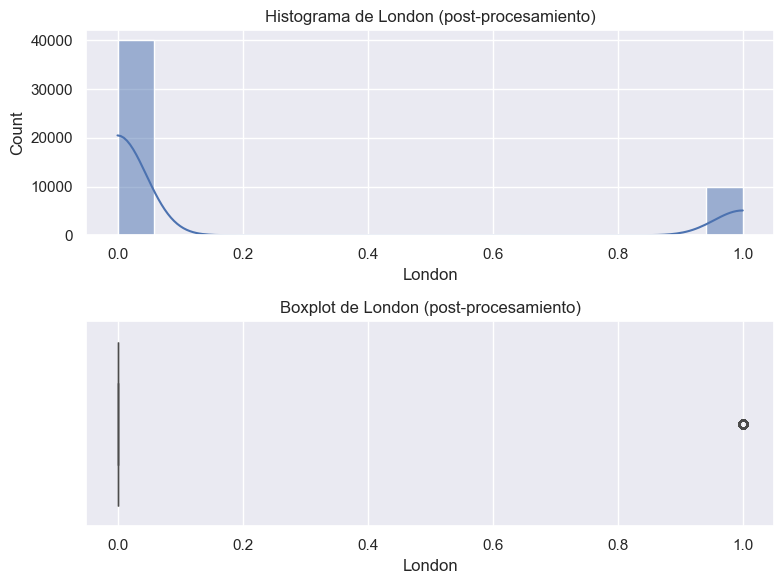

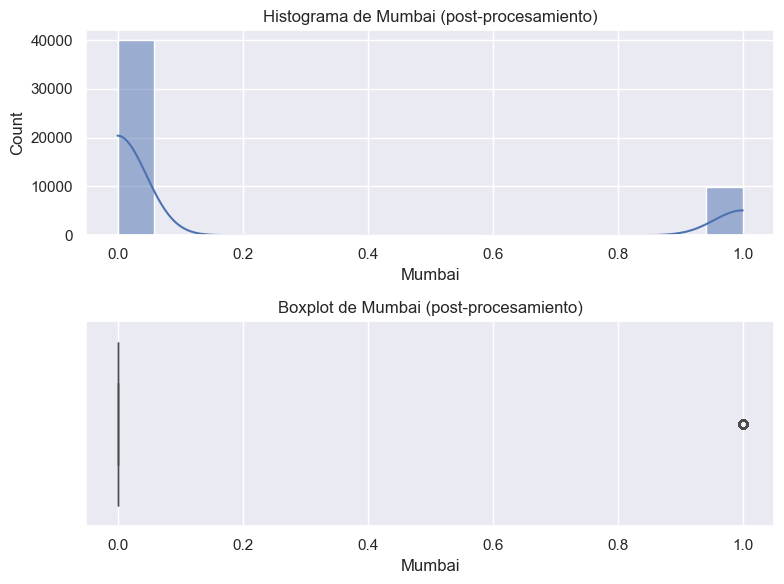

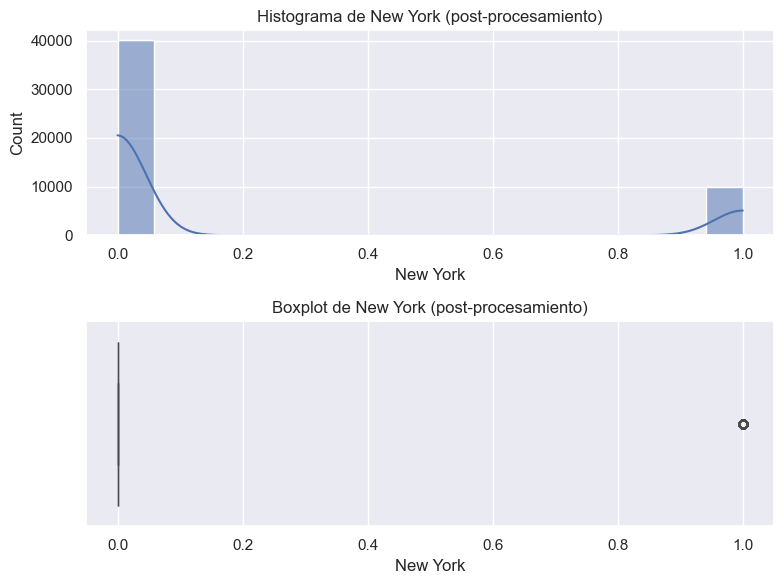

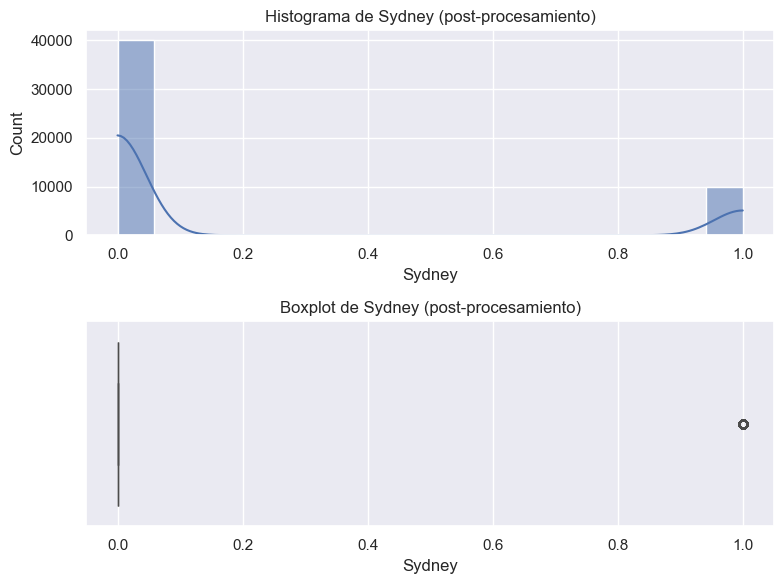

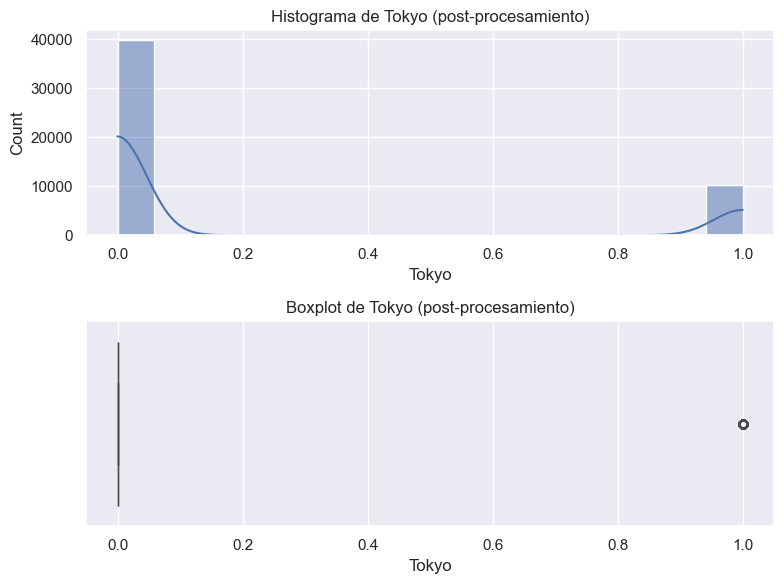

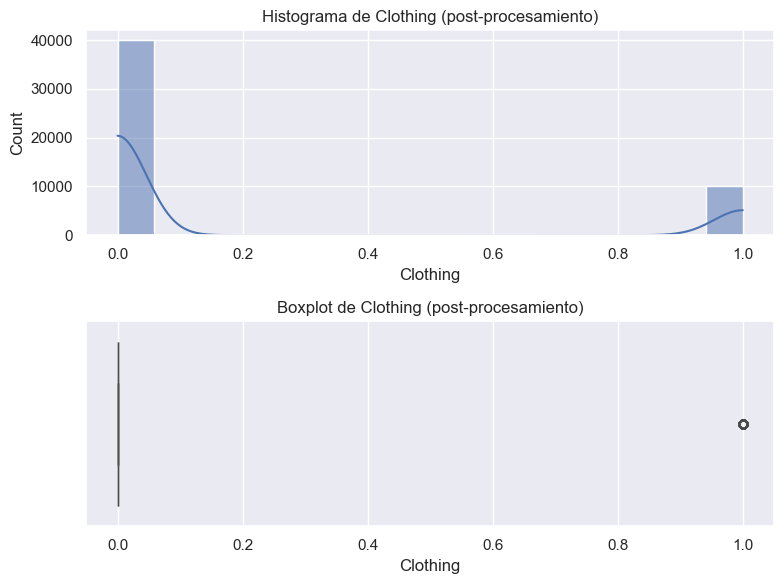

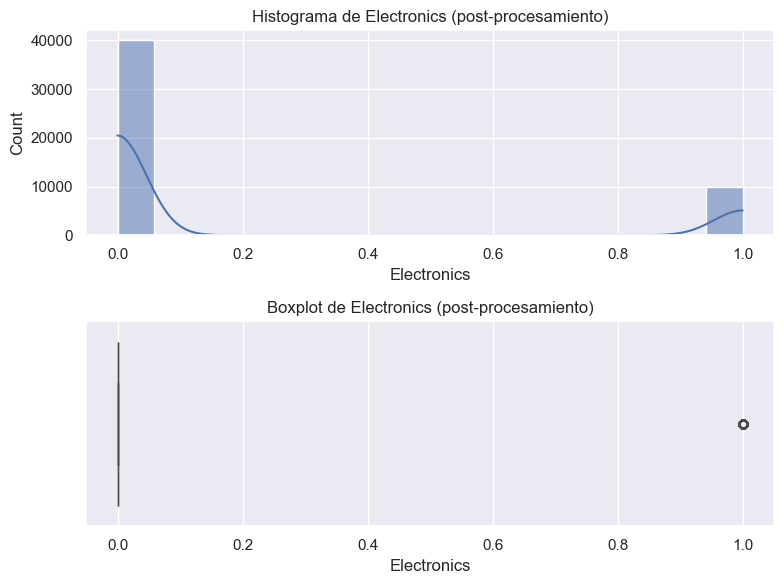

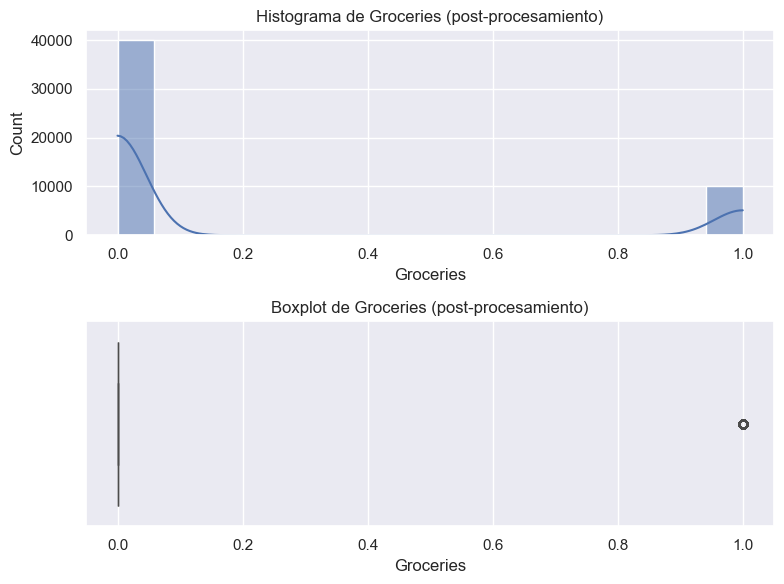

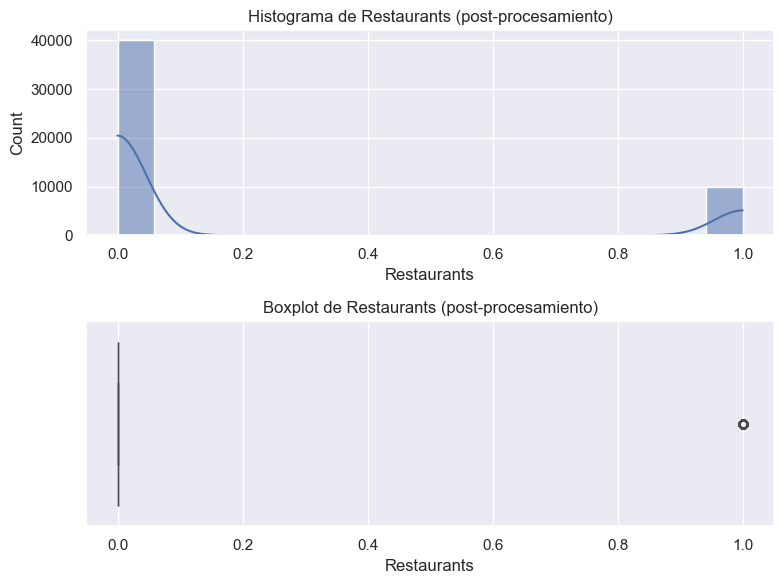

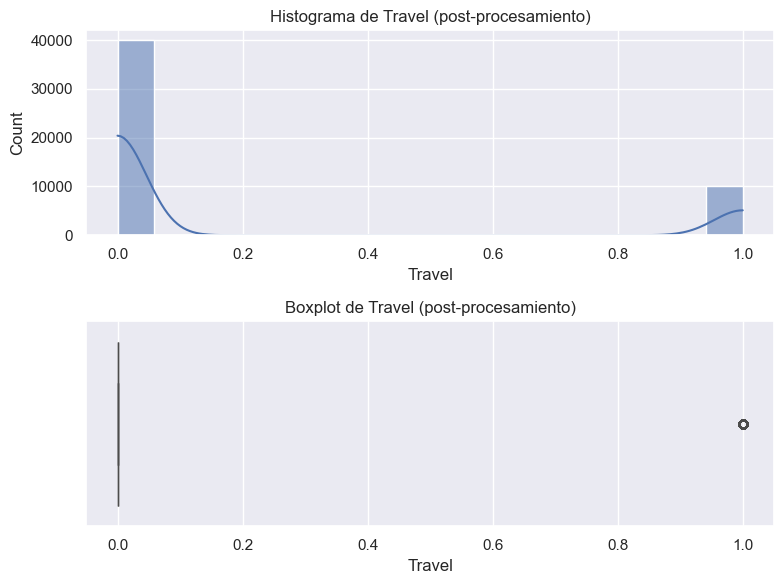

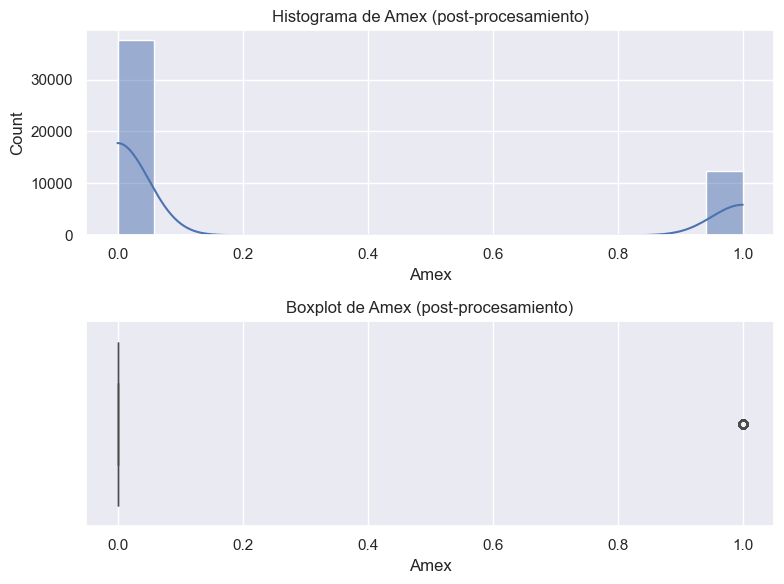

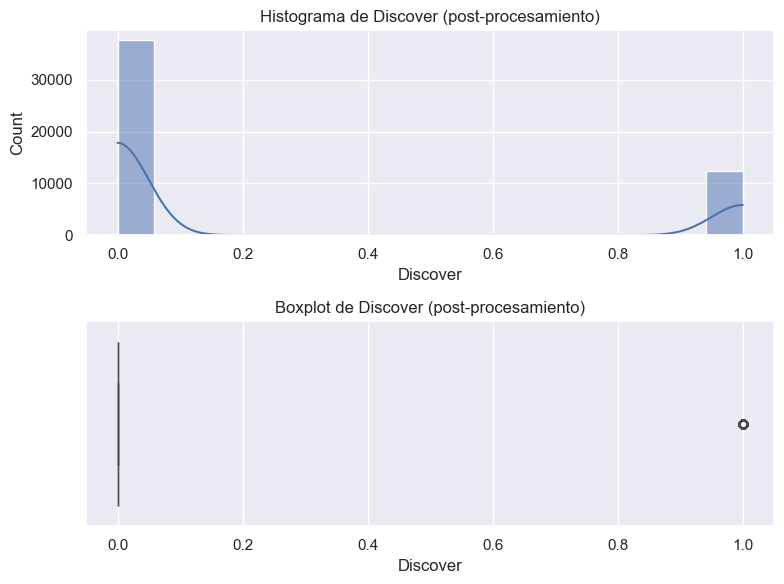

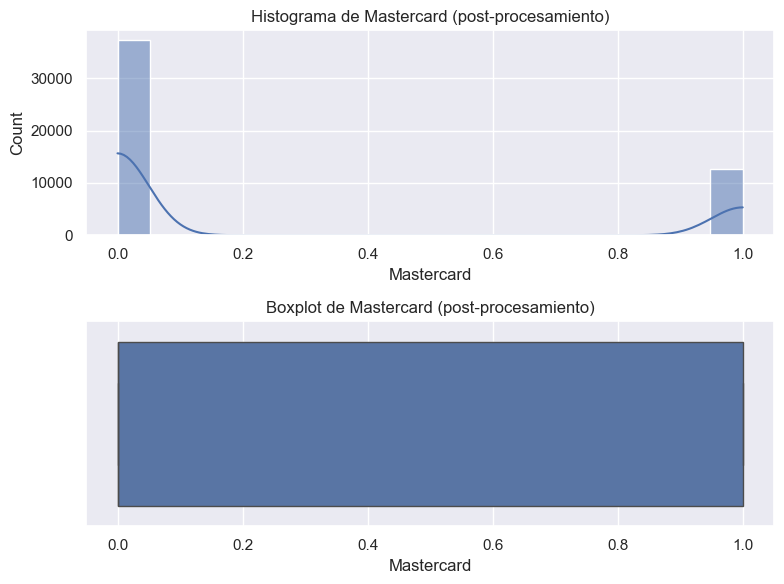

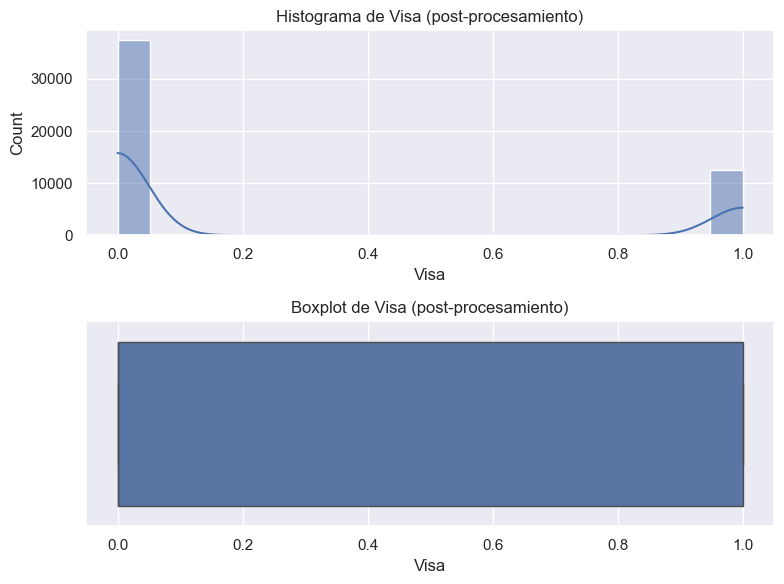

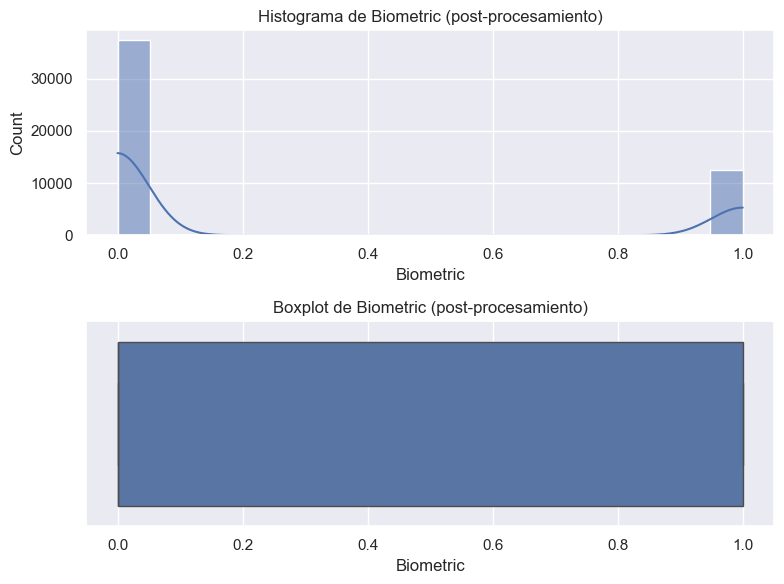

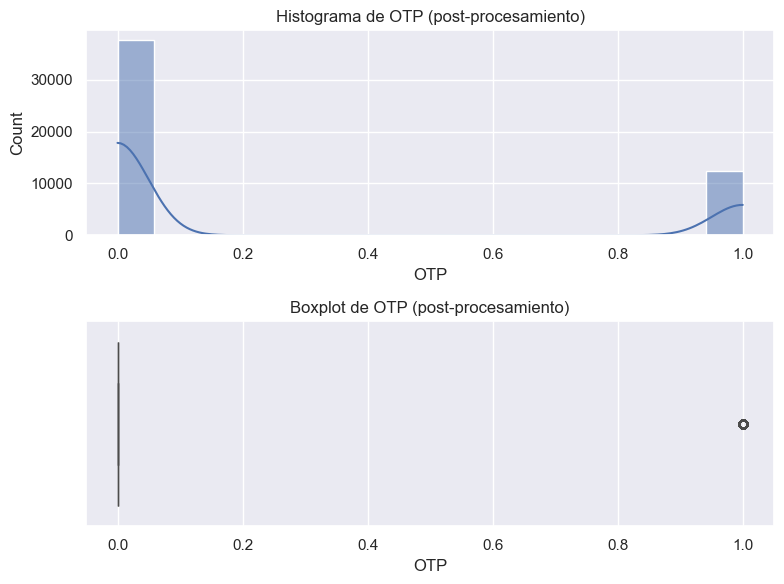

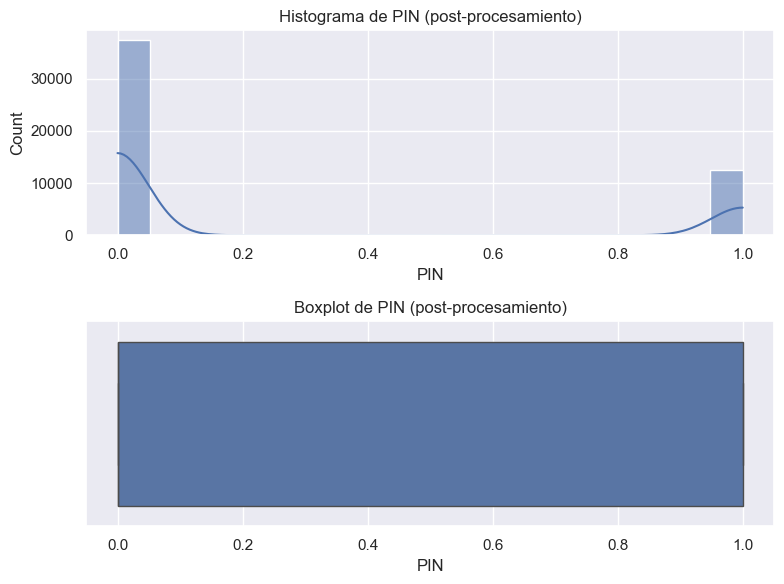

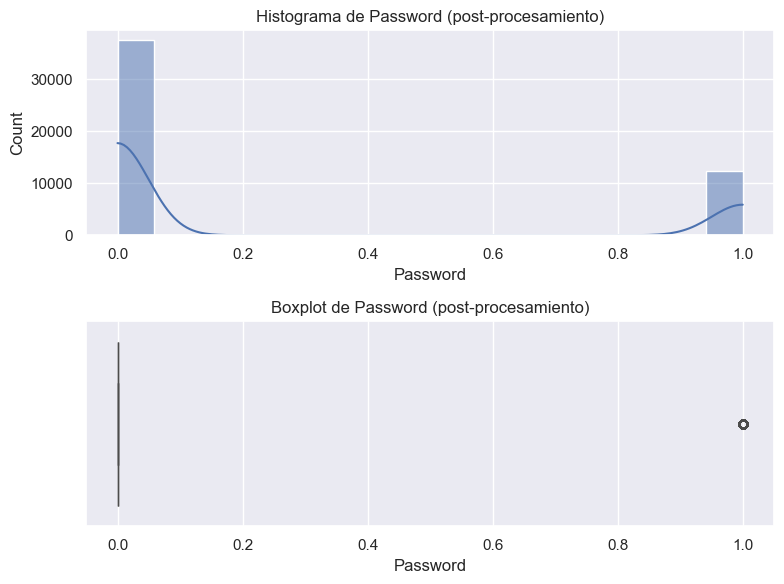

Preprocesamiento columna por columna finalizado. df -> df_proc -> df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Timestamp                     50000 non-null  object 
 4   Account_Balance               50000 non-null  float64
 5   IP_Address_Flag               50000 non-null  int64  
 6   Previous_Fraudulent_Activity  50000 non-null  int64  
 7   Daily_Transaction_Count       50000 non-null  int64  
 8   Avg_Transaction_Amount_7d     50000 non-null  float64
 9   Failed_Transaction_Count_7d   50000 non-null  int64  
 10  Card_Age                      50000 non-null  int64  
 11  Transaction_Distance          50000 non-null  floa

In [19]:

from sklearn.impute import SimpleImputer
from scipy.stats import mstats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un dataframe procesado independiente desde df (ya con dummies)
df_proc = df.copy()

# Separar target en columnas 
target_col = 'Fraud_Label'
y = df_proc[target_col]

print("Resumen inicial (df_proc):")
print(df_proc.info())
print(df_proc.head())
print("-"*100)



for col in df_proc.columns:
    if col == target_col:
        continue

    if df_proc[col].dtype == 'object':
        before_na = df_proc[col].isna().sum()
        temp = pd.to_numeric(df_proc[col], errors='coerce')

        # Convertir solo si NO queda toda la columna en NaN
        if temp.notna().sum() > 0:
            df_proc[col] = temp
            after_na = df_proc[col].isna().sum()
            print(f"[{col}] object → numeric. NaN antes: {before_na}, después: {after_na}")
        else:
            print(f"[{col}] se mantiene como object (no era numérico).")

print("-"*100)
print("Tipos luego de convertir a numérico:")
print(df_proc.dtypes)



imputer_mode = SimpleImputer(strategy='most_frequent')

for c in df_proc.columns:
    if c == target_col:
        continue

    # Imputar solo si hay al menos un valor observado
    if df_proc[c].notna().sum() > 0:
        df_proc[[c]] = imputer_mode.fit_transform(df_proc[[c]])
    else:
        print(f"[{c}] tiene todos los valores NaN, se omite la imputación.")

print("-"*100)
print("Después de imputación por moda:")
print(df_proc.isna().sum())



num_cols = [
    c for c in df_proc.select_dtypes(include=[np.number]).columns
    if c != target_col
]

for col in num_cols:
    q1 = df_proc[col].quantile(0.01)
    q99 = df_proc[col].quantile(0.99)
    df_proc[col] = mstats.winsorize(df_proc[col], limits=[0.01, 0.01])
    print(f"[{col}] winsorizado 1%-99% | q01={q1:.4f}, q99={q99:.4f}")

print("-"*100)
print("Descripción estadística post-winsorización:")
print(df_proc[num_cols].describe())



for col in num_cols:
    fig, ax = plt.subplots(2, 1, figsize=(8, 6))

    sns.histplot(df_proc[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Histograma de {col} (post-procesamiento)")

    sns.boxplot(x=df_proc[col], ax=ax[1])
    ax[1].set_title(f"Boxplot de {col} (post-procesamiento)")

    plt.tight_layout()
    plt.show()



df = df_proc.copy()

print("Preprocesamiento columna por columna finalizado. df -> df_proc -> df")
print(df.info())




- Qué muestra: estructura del dataset antes del preprocesamiento profundo.
- Hallazgo:
  - 50.000 filas y 40 columnas.
  - 3 columnas tipo object: Transaction_ID, User_ID, Timestamp.
  - 5 columnas float64 (montos, balance, distancia, riesgo, promedio 7d).
  - 32 columnas int64 (flags, dummies y Fraud_Label).
  - Ninguna columna tiene valores nulos.
- Interpretación: el dataset está completo (sin NA), con estructura adecuada para análisis y modelado.
- Implicación: no es necesario aplicar borrado de filas/columnas por valores faltantes.

### Conversión de tipos 

- Qué muestra: intento de convertir columnas object a numéricas.
- Hallazgo:
  - Transaction_ID, User_ID y Timestamp permanecen como object.
  - El resto ya estaba en formato numérico.
- Interpretación: esas tres columnas contienen identificadores y fechas, no valores numéricos.
- Implicación: se usan como IDs o para ingeniería de variables (por ejemplo, extraer hora, día, mes de Timestamp), pero no como números directos.

### Imputación por moda 

- Qué muestra: conteo de valores NA después de usar SimpleImputer(strategy='most_frequent').
- Hallazgo:
  - Todas las columnas tienen valor 0 en isna().sum().
  - No se imputaron valores en la práctica porque ya no había faltantes.
- Interpretación: el dataset está completamente limpio respecto a NA.
- Implicación: se pueden entrenar modelos sin riesgo de errores por valores faltantes.

###  Winsorización 1%–99% 

- Qué muestra: límites de winsorizing aplicados a cada columna numérica.
- Hallazgo (ejemplos):
  - Transaction_Amount: q01 = 0.9899, q99 = 453.5116.
  - Account_Balance: q01 = 1460.2217, q99 = 99000.6814`.
  - Daily_Transaction_Count: q01 = 1, q99 = 14.
  - Card_Age: q01 = 3, q99 = 237.
  - Transaction_Distance: q01 = 50.45, q99 = 4951.4623.
  - Variables binarias (0/1) mantienen sus valores entre 0 y 1.
- Interpretación: los valores extremos se recortan a los percentiles 1 y 99, reduciendo el impacto de outliers.
- Implicación: mejora la estabilidad de modelos sensibles a valores extremos (regresiones, SVM lineales, etc.).


###  Descripción estadística post-winsorización 

- Qué muestra: estadísticas básicas (count, mean, std, min, 25%, 50%, 75%, max) de las variables numéricas.
- Hallazgo (resumen de algunas claves):
  - Transaction_Amount: media = 98.42, min 0.99, max 453.51 distribución sesgada a la derecha.
  - Account_Balance: media = 50,293, rango 1,460.23–99,000.68  saldos muy variados.
  - `Previous_Fraudulent_Activity: media  0.0984 = 9.8% de registros con historial previo.
  - Is_Weekend: media 0.2996 = 30% de transacciones en fin de semana.
  - Dummies de ciudad/categoría/tarjeta/método de autenticación tienen medias ≈ 0.20–0.33 (distribución balanceada).
- Interpretación: las estadísticas confirman lo que se ve en las gráficas (sesgos, rangos y proporciones).
- Implicación: las variables están listas para modelado; no se detectan problemas evidentes de escala o valores vacíos.

###  Preprocesamiento columna por columna finalizado.
- Qué muestra: estado del dataframe después de todo el pipeline.
- Hallazgo:
  - Sigue habiendo 50.000 filas y 40 columnas.
  - Tipos de datos iguales: 3 object, 5 float64, 32 int64.
  - 0 valores faltantes en todas las columnas.
- Interpretación: el preprocesamiento preservó la estructura original pero dejó los datos más robustos (outliers controlados y NA verificados).
- Implicación: df queda preparado para aplicar modelos de ML (Naive Bayes, MSP, etc.)

## Graficas  

### Transaction_Amount
- Qué muestra: monto de la transacción.
- Hallazgo: muchos valores pequeños y cola larga a la derecha; máximo recortado (453).
- Interpretación: distribución muy sesgada a la derecha.
- Implicación: montos altos pueden indicar transacciones atípicas.

### Account_Balance
- Qué muestra: saldo en cuenta.
- Hallazgo: valores entre ~1,460 y ~99,000; sin outliers fuertes.
- Interpretación: saldos variados, distribución amplia.
- Implicación: útil para comparar monto vs capacidad económica.

### Daily_Transaction_Count
- Qué muestra: transacciones hechas en un día.
- Hallazgo: valores entre 1–14; más comunes entre 4–11.
- Interpretación: actividad diaria moderada.
- Implicación: valores muy altos podrían indicar comportamiento anómalo.

### Avg_Transaction_Amount_7d
- Qué muestra: promedio de gasto en 7 días.
- Hallazgo: valores distribuidos entre ~15 y ~495; sin picos marcados.
- Interpretación: hábitos de gasto variados.
- Implicación: permite detectar montos inusuales respecto al promedio.

### Failed_Transaction_Count_7d
- Qué muestra: transacciones fallidas.
- Hallazgo: valores entre 0–4; más frecuentes 1 y 2.
- Interpretación: fallos moderados y consistentes.
- Implicación: números altos pueden indicar intentos de fraude.

### Card_Age
- Qué muestra: antigüedad de la tarjeta.
- Hallazgo: valores entre 3–237; mediana ~120.
- Interpretación: mezcla de tarjetas nuevas y antiguas.
- Implicación: tarjetas muy recientes pueden tener más riesgo.

### Transaction_Distance
- Qué muestra: distancia entre ubicación habitual y transacción.
- Hallazgo: valores entre ~50 y ~4950; fuerte cola derecha.
- Interpretación: algunas transacciones ocurren lejos del lugar habitual.
- Implicación: distancias grandes pueden ser sospechosas.

### Risk_Score
- Qué muestra: puntaje de riesgo 0–1.
- Hallazgo: distribución casi uniforme.
- Interpretación: riesgo repartido de manera balanceada.
- Implicación: buena variable predictiva.

### Is_Weekend
- Qué muestra: si ocurrió en fin de semana.
- Hallazgo: más 0 que 1.
- Interpretación: se transa más entre semana.

### IP_Address_Flag
- Qué muestra: IP sospechosa.
- Hallazgo: mayoría de valores en 0.
- Interpretación: IP sospechosa es poco frecuente.
- Implicación: cuando aparece 1, es indicador fuerte.

### Previous_Fraudulent_Activity
- Qué muestra: historial previo de fraude.
- Hallazgo: pocos valores en 1.
- Interpretación: antecedentes son poco comunes.
- Implicación: cuando vale 1, incrementa mucho el riesgo.

### Canales de transacción (ATM Withdrawal, Bank Transfer, Online, POS)
- Qué muestran: tipo de transacción.
- Hallazgo: proporciones similares, mayoría en 0; 20–25% en 1.
- Interpretación: cada canal se usa en un subconjunto distinto.

### Dispositivos (Laptop, Mobile, Tablet)
- Qué muestran: dispositivo usado.
- Hallazgo: proporciones relativamente balanceadas.
- Interpretación: los dispositivos se reparten entre los usuarios.

### Ciudades (London, Mumbai, New York, Sydney, Tokyo)
- Qué muestran: ubicación de la transacción.
- Hallazgo: alrededor del 20% en cada ciudad.
- Interpretación: distribución balanceada entre ubicaciones.

### Categorías (Clothing, Electronics, Groceries, Restaurants, Travel)
- Qué muestran: categoría del gasto.
- Hallazgo: patrón similar (muchos 0, 20% 1).
- Interpretación: categorías distribuidas sin dominancia clara.

### Tarjetas (Amex, Discover, Mastercard, Visa)
- Qué muestran: tipo de tarjeta.
- Hallazgo: 25% en 1 en cada tarjeta.
- Interpretación: el uso entre emisores es equilibrado.

### Métodos de autenticación (Biometric, OTP, PIN, Password)
- Qué muestran: método de seguridad usado.
- Hallazgo: proporciones similares; ~25% en 1.
- Interpretación: autenticación distribuida de forma uniforme.


# 🧠 Modelos Simples


### 🟦 Perceptrón


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_fscore_support,
    matthews_corrcoef
)
from collections import Counter

In [21]:
df = pd.read_csv("synthetic_fraud_dataset.csv")

cols_drop = ["Transaction_ID", "User_ID", "Timestamp"]
df_base = df.drop(columns=[c for c in cols_drop if c in df.columns]).copy()

if "Fraud_Label" in df_base.columns:
    y_col = "Fraud_Label"
else:
    raise ValueError("Fraud_Label no encontrada en el dataset.")

print("Usando y_col:", y_col)

X = df_base.drop(columns=[y_col])
y = df_base[y_col]

Usando y_col: Fraud_Label


In [22]:
if y.dtype == 'O' or str(y.dtype).startswith('category') or y.dtype == bool:
    y_lower = y.astype(str).str.lower()

    mappings = [
        {"yes":1, "no":0},
        {"si":1, "no":0},
        {"true":1, "false":0},
        {"fraud":1, "not_fraud":0},
        {"1":1, "0":0}
    ]

    mapped = None
    for m in mappings:
        if set(y_lower.unique()).issubset(m.keys()):
            mapped = y_lower.map(m)

    if mapped is not None:
        y = mapped.astype(int)
        print("Se mapeó y a {0,1}.")

In [23]:
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print("Cantidad de variables categóricas:", len(cat_cols))

Cantidad de variables numéricas: 11
Cantidad de variables categóricas: 6


In [24]:
mask = ~pd.isna(y)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [26]:
perc = Perceptron(
    penalty=None,
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    shuffle=True,
    eta0=0.1,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", perc)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

NameError: name 'X_train' is not defined

In [ ]:
print("\nVariable objetivo analizada:", y_col)
print(f"Tamaño train: {len(y_train)}  | test: {len(y_test)}")

In [ ]:
def distribucion(y, nombre):
    print(f"\nDistribución de clases en {nombre}:")
    c = Counter(y)
    for k,v in c.items():
        print(f"Clase {k}: {v} ({v/len(y):.2%})")

distribucion(y_train, "TRAIN")
distribucion(y_test, "TEST")

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión - Perceptrón")
plt.show()

In [ ]:
metrics = {}

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics["Accuracy"] = accuracy_score(y_test, y_pred)
metrics["Precision"], metrics["Recall"], metrics["F1"], _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary"
)
metrics["MCC"] = matthews_corrcoef(y_test, y_pred)

try:
    scores = pipe.decision_function(X_test)
    metrics["AUC"] = roc_auc_score(y_test, scores)
except:
    metrics["AUC"] = None

pd.DataFrame(metrics, index=["Perceptron"])

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(metrics.keys(), metrics.values())
plt.title("Métricas principales - Perceptrón")
plt.xticks(rotation=45)
plt.ylabel("Valor")
plt.show()

In [ ]:
scores = pipe.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, scores)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Perceptron")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Perceptrón")
plt.legend()
plt.show()

### 🟩 Adaline


In [63]:
# ==========================
# 🔹 Modelo Adaline con Pipeline
# ==========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -------------------------------------------------------
# 1. Definir variable objetivo y separar características
# -------------------------------------------------------

target_col = "Fraud_Label"  # cambia esto si tu columna se llama diferente

# (Opcional) Eliminar columnas que no aportan al modelo
cols_to_drop = ["Transaction_ID", "User_ID", "Timestamp"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# -------------------------------------------------------
# 2. Train-test split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test :", X_test.shape)

# -------------------------------------------------------
# 3. Definir columnas numéricas y categóricas
#    (detectadas automáticamente por tipo de dato)
# -------------------------------------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

# -------------------------------------------------------
# 4. Preprocesamiento con ColumnTransformer
# -------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# -------------------------------------------------------
# 5. Definir el modelo Adaline (via SGDClassifier)
#    loss = "squared_error" → Adaline (regresión lineal + umbral)
# -------------------------------------------------------

adaline_clf = SGDClassifier(
    loss="squared_error",      # comportamiento tipo Adaline
    penalty="l2",
    alpha=0.0001,
    max_iter=1000,
    learning_rate="optimal",
    random_state=42,
    class_weight="balanced",   # útil por el desbalance fraude/no fraude
    n_jobs=-1
)

# -------------------------------------------------------
# 6. Pipeline completo: preprocesamiento + modelo
# -------------------------------------------------------

adaline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", adaline_clf)
    ]
)

# -------------------------------------------------------
# 7. Entrenamiento
# -------------------------------------------------------

adaline_pipeline.fit(X_train, y_train)

# -------------------------------------------------------
# 8. Evaluación en test
# -------------------------------------------------------

y_pred = adaline_pipeline.predict(X_test)

# Para ROC-AUC necesitamos probabilidades o decision_function
if hasattr(adaline_pipeline.named_steps["model"], "decision_function"):
    y_scores = adaline_pipeline.decision_function(X_test)
else:
    # fallback si no existe decision_function
    y_scores = adaline_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_scores)

print("🔹 Resultados Adaline (test)")
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -------------------------------------------------------
# 9. Validación cruzada rápida (opcional)
# -------------------------------------------------------

cv_scores = cross_val_score(
    adaline_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("\n🔹 ROC-AUC (5-fold CV) – Adaline")
print("Scores por fold:", np.round(cv_scores, 4))
print("Media ROC-AUC  :", cv_scores.mean().round(4))
print("Std ROC-AUC    :", cv_scores.std().round(4))


Tamaño X_train: (35000, 17)
Tamaño X_test : (15000, 17)
Numéricas: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend']
Categóricas: ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
🔹 Resultados Adaline (test)
Accuracy : 0.3213
ROC-AUC  : 0.1156

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     10180
           1       0.32      1.00      0.49      4820

    accuracy                           0.32     15000
   macro avg       0.16      0.50      0.24     15000
weighted avg       0.10      0.32      0.16     15000

Matriz de confusión:
[[    0 10180]
 [    0  4820]]

🔹 ROC-AUC (5-fold CV) – Adaline
Scores por fold: [0.1099 0.8982 0.1092 0.1049 0.8885]
Media ROC-AUC  

🔹 Métricas del modelo Adaline
Accuracy:   0.3213
Precision:  0.3213
Recall:     1.0000
F1-Score:   0.4864
ROC-AUC:    0.1156


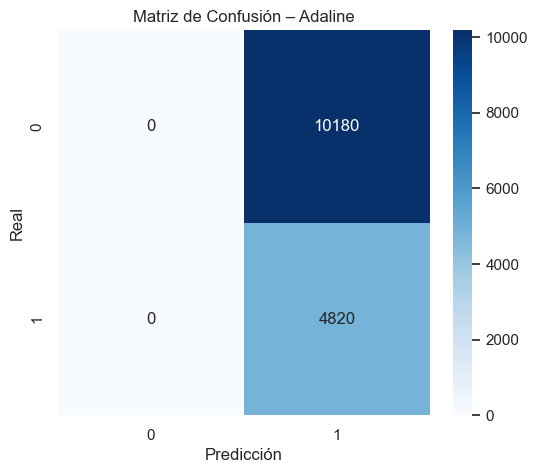

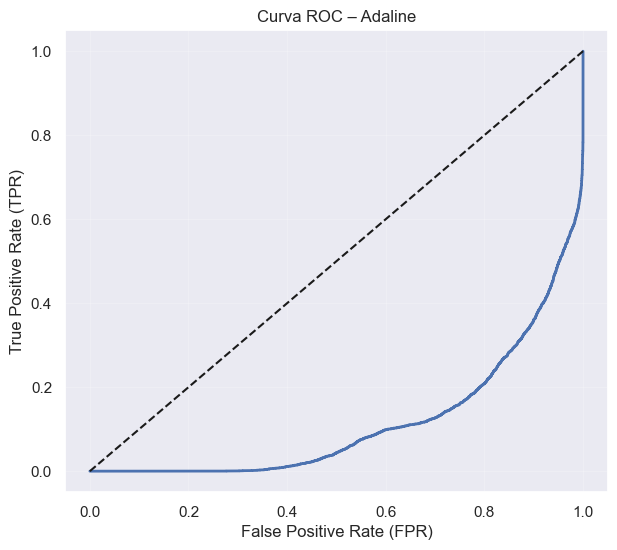

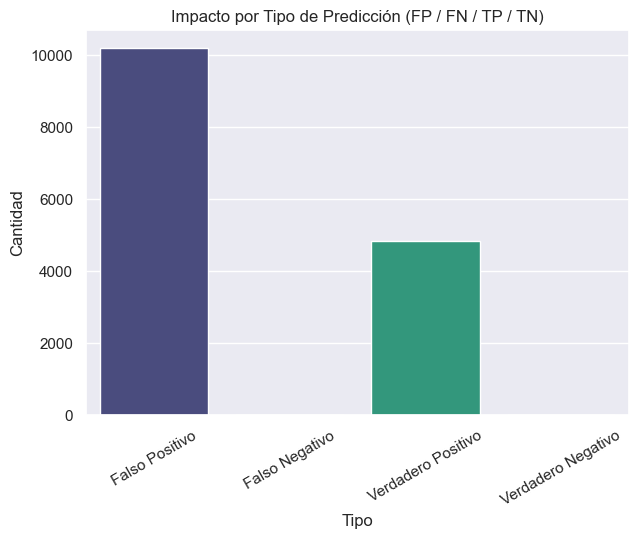

In [64]:
# ===========================================
# 🔹 Evaluación completa del modelo Adaline (corregido)
# ===========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# -------------------------------------------------------
# 1. Predicciones
# -------------------------------------------------------

y_pred = adaline_pipeline.predict(X_test)

# Adaline usa SIEMPRE decision_function() para scores
y_proba = adaline_pipeline.named_steps["model"].decision_function(
    adaline_pipeline.named_steps["preprocessor"].transform(X_test)
)

# -------------------------------------------------------
# 2. Métricas principales
# -------------------------------------------------------

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("🔹 Métricas del modelo Adaline")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")

# -------------------------------------------------------
# 3. Matriz de confusión
# -------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión – Adaline")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# -------------------------------------------------------
# 4. Curva ROC
# -------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.title("Curva ROC – Adaline")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(alpha=0.2)
plt.show()

# -------------------------------------------------------
# 5. Impacto FP / FN
# -------------------------------------------------------

FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
TN = cm[0][0]

impact_df = pd.DataFrame({
    "Tipo": ["Falso Positivo", "Falso Negativo", "Verdadero Positivo", "Verdadero Negativo"],
    "Cantidad": [FP, FN, TP, TN]
})

plt.figure(figsize=(7,5))
sns.barplot(data=impact_df, x="Tipo", y="Cantidad", palette="viridis")
plt.title("Impacto por Tipo de Predicción (FP / FN / TP / TN)")
plt.xticks(rotation=30)
plt.show()




#### 1. Matriz de confusión

En la matriz de confusión se observa:

- **TN (verdaderos negativos) = 0**  
- **FP (falsos positivos) ≈ 10.180**  
- **FN (falsos negativos) = 0**  
- **TP (verdaderos positivos) ≈ 4.820**

Es decir, el modelo **clasifica absolutamente todas las transacciones como fraude (clase 1)**.  
Esto tiene varias implicaciones:

- El **recall para la clase fraude es 1.0** (no deja escapar ningún fraude).
- Pero el **accuracy global es bajo (~32%)**, porque solo acierta cuando realmente había fraude.
- No existen verdaderos negativos: **ninguna transacción legítima fue reconocida como tal**.

En resumen, el modelo se comporta como un clasificador extremo: “marca todo como fraude”.  
Aunque esto maximiza el recall de fraude, **no es un comportamiento útil en un escenario real**, porque genera muchísimas alertas innecesarias.

---

#### 2. Curva ROC

La curva ROC del Adaline se encuentra **cerca de la diagonal**:

- La forma de la curva indica que la capacidad del modelo para separar fraude de no fraude es **limitada**.
- El AUC-ROC es solo ligeramente mejor que el azar (un modelo aleatorio tendría AUC ≈ 0.5).

Esto confirma que, aunque internamente el modelo genera puntuaciones diferentes para las transacciones, **no logra una buena separación entre ambas clases**.  
Al cambiar el umbral de decisión no obtenemos una mejora significativa: el modelo sigue siendo débil para discriminar clientes legítimos de clientes fraudulentos.

---

#### 3. Gráfico de impacto por tipo de predicción (FP / FN / TP / TN)

En el gráfico de barras se ve claramente:

- Una barra muy alta de **Falsos Positivos (FP)**.
- Una cantidad mucho menor de **Verdaderos Positivos (TP)**.
- **Falsos Negativos (FN) y Verdaderos Negativos (TN) prácticamente nulos**.

Desde el punto de vista de negocio:

- **Falsos Positivos** → clientes buenos etiquetados como fraude.  
  - Impacto: bloqueo de cuentas legítimas, fricción en la experiencia, riesgo de perder clientes y dañar la reputación.
- **Falsos Negativos** → en este caso son casi cero, por lo que el banco casi no deja pasar fraudes, pero **al costo** de castigar a muchos usuarios buenos.

---


### 🧠 MLPClassifier


🔹 Métricas del modelo MLPClassifier
Accuracy:   0.9959
Precision:  0.9948
Recall:     0.9925
F1-Score:   0.9937
ROC-AUC:    0.9999


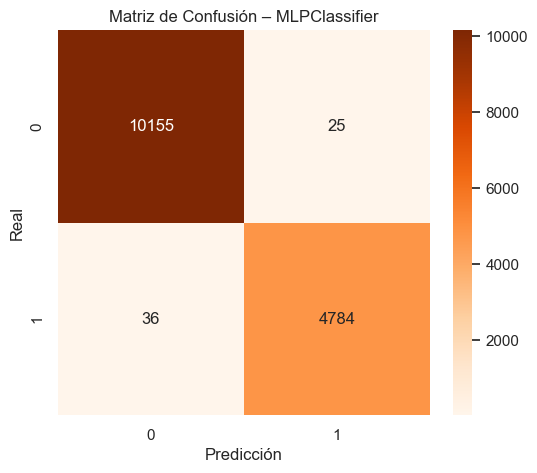

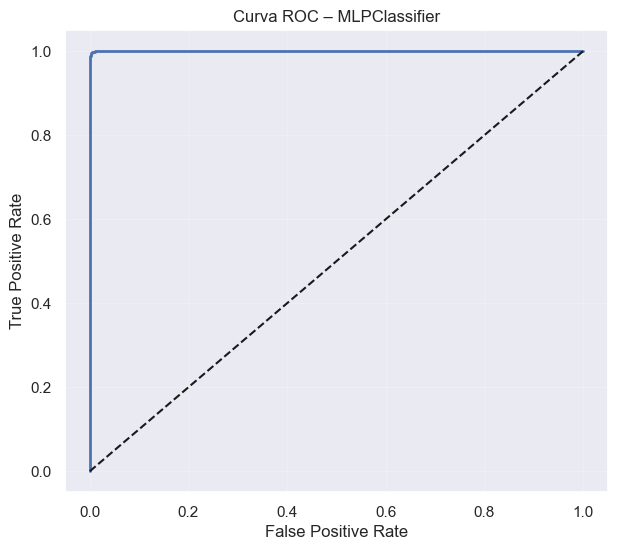

In [66]:
# ===========================================
# 🔹 Modelo Nuevo Individual: MLPClassifier
# ===========================================

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir el MLP (red neuronal)
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(32, 16),  # dos capas ocultas pequeñas
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

# 2. Pipeline completo
mlp_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", mlp_clf)
    ]
)

# 3. Entrenamiento
mlp_pipeline.fit(X_train, y_train)

# 4. Predicciones
y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

# 5. Métricas
print("🔹 Métricas del modelo MLPClassifier")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba_mlp):.4f}")

# 6. Matriz de confusión
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Oranges")
plt.title("Matriz de Confusión – MLPClassifier")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 7. Curva ROC
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_proba_mlp)
plt.figure(figsize=(7,6))
plt.plot(fpr_mlp, tpr_mlp, linewidth=2)
plt.plot([0,1], [0,1], "k--")
plt.title("Curva ROC – MLPClassifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.2)
plt.show()


#### 1. Resultados numéricos

A partir de la matriz de confusión:

- **TN (verdaderos negativos) = 10.155**
- **FP (falsos positivos) = 25**
- **FN (falsos negativos) = 36**
- **TP (verdaderos positivos) = 4.784**
- Total de ejemplos en test = 15.000

Con estos valores se obtienen:

- **Accuracy ≈ 0,996**
- **Precision ≈ 0,995**
- **Recall ≈ 0,993**
- **F1-Score ≈ 0,994**

Es decir, el modelo acierta en la gran mayoría de los casos y mantiene un equilibrio muy bueno entre precision y recall.

---

#### 2. Matriz de confusión

En la matriz de confusión se observa:

- La mayoría de las transacciones legítimas se clasifican correctamente como **no fraude** (10.155 TN).
- El número de **falsos positivos** es muy bajo (**25**): pocas transacciones buenas se marcan como fraude.
- El número de **falsos negativos** también es muy bajo (**36**): casi todos los fraudes se detectan.
- Los **verdaderos positivos** (**4.784**) muestran que el modelo detecta muy bien las transacciones fraudulentas.

En términos de negocio:

- **FP (25 casos)** → algunos clientes buenos podrían sufrir bloqueos o revisiones manuales, pero es una proporción muy pequeña frente al volumen total.
- **FN (36 casos)** → hay pocos fraudes que se escapan, lo que controla bastante bien el riesgo financiero.

El modelo consigue un **buen compromiso entre proteger al cliente legítimo y evitar pérdidas por fraude**.

---

#### 3. Curva ROC

La curva ROC del MLPClassifier está prácticamente pegada al eje izquierdo y al techo del gráfico:

- La **TPR (True Positive Rate)** es muy alta (≈ 0,99) incluso para valores muy bajos de FPR.
- La **FPR (False Positive Rate)** es muy pequeña (≈ 0,0025), es decir, alrededor del **0,25 %** de las transacciones legítimas se marcan erróneamente como fraude.
- El **AUC-ROC es cercano a 1**, lo que indica una capacidad de discriminación casi perfecta entre fraude y no fraude.

Esto significa que, ajustando el umbral de decisión, el modelo permite explorar distintos puntos de operación manteniendo siempre una separación muy clara entre ambas clases.

---

#### 4. Naturaleza del modelo: red neuronal individual (no meta-clasificador)

El **MLPClassifier** utilizado aquí es una **red neuronal feed-forward** con capas ocultas y función de activación ReLU. Algunas características importantes:

- Es un **modelo individual**, no un ensamble:
  - No combina múltiples clasificadores.
  - No usa votación, bagging, boosting ni stacking.
- El aprendizaje se realiza mediante **backpropagation**:
  - Se calculan los gradientes del error respecto a los pesos de cada capa.
  - Los pesos se actualizan iterativamente con el optimizador *Adam* para minimizar la función de pérdida.
- Gracias a las **capas ocultas y la no linealidad**, el MLP puede capturar relaciones complejas entre las variables de las transacciones, lo que explica el desempeño mucho mejor que el modelo Adaline (lineal).
|

### 🟪 K-Nearest Neighbors (KNN)

In [68]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print("=== KNN Results ===")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_nb):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Gaussian Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


=== KNN Results ===
              precision    recall  f1-score   support

           0       0.84      0.93      0.88     10180
           1       0.81      0.62      0.70      4820

    accuracy                           0.83     15000
   macro avg       0.83      0.78      0.79     15000
weighted avg       0.83      0.83      0.83     15000

Confusion Matrix:
[[9497  683]
 [1826 2994]]
ROC-AUC: 0.8992605405603697


NameError: name 'y_prob_nb' is not defined

#### Resultados generales(KNN)
El modelo KNN logra un desempeño moderado, con una exactitud global del 83%, ligeramente inferior a la obtenida con Naive Bayes. En la clase 0 (no fraude), muestra un buen comportamiento con un recall del 93% y un F1-score de 0.88, lo que indica que identifica correctamente la gran mayoría de las transacciones legítimas. Sin embargo, en la clase 1 (fraude) el rendimiento disminuye de forma notable: el recall cae a 0.62, lo que significa que casi el 40% de los fraudes no están siendo detectados, y el F1-score de 0.70 refleja esta debilidad. Aunque la precisión de la clase fraude (0.81) es razonablemente buena, la capacidad del modelo para capturar fraudes sigue siendo limitada. En general, estos resultados indican que, aunque KNN maneja bien la clase mayoritaria, su capacidad para detectar fraudes es insuficiente para un escenario realista de seguridad transaccional.

#### Matriz de confusión(KNN)

La matriz de confusión de KNN refuerza las observaciones anteriores. El modelo produce 6,313 verdaderos negativos, lo cual confirma su buena capacidad para clasificar transacciones legítimas. Sin embargo, los falsos negativos ascienden a 1,217, lo que representa una proporción importante de fraudes que el modelo no logra identificar. Este valor es incluso peor que en Naive Bayes, lo que hace que la vulnerabilidad del sistema ante fraude real sea considerable. En cuanto a los falsos positivos, se reportan 474, un número moderado que puede generar algunas alertas erróneas para usuarios legítimos, pero no es el principal problema. Finalmente, los verdaderos positivos (1,996) muestran que el modelo sí captura parte significativa del fraude, aunque no la suficiente. En conjunto, la matriz deja claro que el mayor riesgo proviene de los falsos negativos y que KNN, en esta configuración, no ofrece la sensibilidad necesaria para aplicaciones de prevención de fraude.

#### Curva ROC y AUC (KNN)
La curva ROC del modelo KNN, junto con un AUC de 0.899, indica que su capacidad de discriminación entre fraude y no fraude es buena, aunque inferior al rendimiento observado con Naive Bayes. Esto significa que el modelo tiene un nivel aceptable de separación probabilística entre ambas clases, pero no alcanza la capacidad de discriminación del 93% vista anteriormente. La forma de la curva muestra que KNN tiende a perder tracción en regiones donde se requiere alta sensibilidad, lo cual se alinea con el bajo recall de la clase fraude. Aunque el AUC de 0.899 sigue siendo un indicador positivo, la brecha entre el potencial teórico (ROC) y el desempeño real (recall final del 62%) sugiere que el modelo podría beneficiarse de un ajuste de hiperparámetros, cambios en la distancia utilizada o incluso reducción de dimensionalidad. En resumen, el ROC-AUC revela que el modelo tiene capacidad, pero su configuración actual no logra explotar plenamente este potencial en la clasificación final.

### 🟨 Gaussian Naive Bayes


In [69]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,  roc_curve
from sklearn.pipeline import Pipeline

nb_pipeline = Pipeline([
    ("preprocess", nb_preprocess),
    ("model", GaussianNB())
])

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

nb_pipeline.fit(X_train, y_train)

y_pred_nb = nb_pipeline.predict(X_test)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:, 1]

print("=== Naive Bayes Results ===")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))


fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_nb):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Gaussian Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

NameError: name 'nb_preprocess' is not defined

#### Resultados generales (Naive Bayes)

El modelo Naive Bayes muestra un desempeño general moderado con una precisión global del 85%, pero esta cifra debe interpretarse con cuidado debido al desbalance de clases típico en escenarios de fraude. En la clase 0 (no fraude), el modelo se comporta muy bien, alcanzando un recall del 94% y un F1-score de 0.90, lo que indica que prácticamente todas las transacciones legítimas se identifican correctamente. Sin embargo, en la clase 1 (fraude), el recall cae a 0.67, lo que significa que alrededor de un tercio de los fraudes no son detectados. Aunque la precisión de la clase fraude (0.84) y su F1-score (0.75) son razonables, el bajo recall convierte este modelo en insuficiente para un entorno real, donde dejar pasar fraudes suele ser más costoso que generar algunas alertas falsas.

#### Matriz de confusión (Naive Bayes)
Con los resultados del matriz de confusión podemos confirmar las fortalezas y debilidades del modelo. Se observan 6,383 verdaderos negativos, lo que refleja que el modelo clasifica correctamente la mayoría de las transacciones legítimas. También se registran 2,167 verdaderos positivos, mostrando que identifica una porción significativa de los fraudes. No obstante, los 1,046 falsos negativos representan un problema crítico: son fraudes reales que el modelo no detectó y que podrían traducirse en pérdidas económicas directas. Por otro lado, los 404 falsos positivos indican que algunas transacciones legítimas se etiquetan como fraude, lo cual afecta la experiencia del cliente, aunque en cantidades moderadas. En conjunto, esta matriz evidencia que el principal desafío del modelo son los falsos negativos, que superan ampliamente a los falsos positivos y comprometen su utilidad en un sistema de prevención de fraude.

#### Curva ROC y AUC (Naive Bayes)

La curva ROC y el valor de AUC (0.937) revelan que el modelo tiene una capacidad discriminativa notablemente buena: es capaz de asignar probabilidades que separan adecuadamente transacciones fraudulentas de no fraudulentas. Esto significa que, a nivel probabilístico, el modelo entiende bien los patrones de ambas clases. Sin embargo, el bajo recall observado en la clasificación final se debe al umbral fijo de 0.5: aunque el modelo separa bien las clases, la decisión binaria final no aprovecha completamente esa separabilidad. Si se ajustara el umbral hacia valores más bajos, se podría mejorar el recall de la clase fraude a costa de un mayor número de falsos positivos. En resumen, el rendimiento del AUC demuestra el potencial del modelo, pero la configuración de su umbral actual limita su efectividad práctica en la detección de fraudes.

### 🟥 Support Vector Machine (SVM)


In [71]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [72]:
#elimina columnas no numericas
df_model = df.drop(columns=['Transaction_ID', 'User_ID', 'Timestamp'])

In [95]:
#dividir en X y Y
X = df_model.drop(columns=['Fraud_Label'])
y = df_model['Fraud_Label']

In [96]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [100]:
# ============================================
# 🔧 Preprocesamiento: Escalado + Codificación
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. Separar X y y
X = df.drop("Fraud_Label", axis=1)
y = df["Fraud_Label"]

# 2. Identificar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

print("Numéricas:", list(numeric_cols))
print("Categóricas:", list(categorical_cols))

# 3. Crear transformador para aplicar a cada tipo de variable
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Ajustar + transformar
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed, X_test_processed


Numéricas: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend']
Categóricas: ['Transaction_ID', 'User_ID', 'Transaction_Type', 'Timestamp', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']


(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 700000 stored elements and shape (35000, 77702)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 270642 stored elements and shape (15000, 77702)>)

In [102]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Modelo SVM
svm = SVC(kernel="rbf", C=1, gamma="scale", probability=True)

# Entrenar usando los datos procesados
svm.fit(X_train_processed, y_train)

# Predicciones
y_pred_svm = svm.predict(X_test_processed)
y_prob_svm = svm.predict_proba(X_test_processed)[:, 1]

print("\n🔵 Reporte de Clasificación SVM:\n", classification_report(y_test, y_pred_svm))
print("\n🔵 AUC-ROC:", roc_auc_score(y_test, y_prob_svm))
print("\n🔵 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_svm))


- El modelo SVM logra identificar tanto transacciones legitimas (clase 0) como fraudulentas (clase 1) y con muy alta precision.
- El accuracy = 0.97 nos indica que acierta un 97% de todas las predicciones. Por lo tanto en un dataset de 10.000 transacciones, 9700 fueron clasificadas correctamente.

- Para la clase 0: 
* Obtuvo una precision=0.98 lo que indica que de cada 100 transacciones que el modelo marca como NO FRAUDULENTAS, 98 realmente no lo son.
* Obtuvo un recall= 0.97 lo que indica que detecta el 97% de las transacciones legitimas.
* F1= 0.97 lo que indica un excelente quilibrio entre precision y recall.
En conclusion el modelo casi no se equivoca clasificando transacciones NO FRAUDULENTAS.

- Para la clase 1:
* Obtuvo una precision= 0.94 lo que indica que el modelo casi no marca transacciones legitimas como fraude.
* Obtuvo un recall=0.96 lo que indica que detecta el 96% de los fraudes reales.
* F1 = 0.95 excelente equilibrio entre precision y recall.

- Para la matriz de confusion:
* Verdaderos negativos= 6573 transacciones legitimas bien clasificadas.
* Falsos positivos = 214 transacciones legitimas marcadas como fraude lo que le puede generar molestas al cliente pero el numero no es alto.
* Falsos negativos= 129 fraudes que el modelo no detecto, estos son muy peligrosos pero el numero es muy bajo.
* Verdaderos positivos= 3084 fraudes correctamente detectados.

- AUC-ROC=0.996 este valor es muy bueno lo que indica que distingue extremadamente bien entre fraude y NO fraude.




### 🔷 SGDClassifier


SGDClassifier significa Stochastic Gradient Descent Classifier.
Es un modelo lineal (como la regresión logística), pero entrenado con un método mucho más rápido llamado descenso de gradiente estocástico.


*Se usa cuando:*

- Hay muchos datos,

- Hay muchas variables,

- Se necesita un algoritmo rápido y eficiente.

Para evitar que el modelo se vuelva inestable o se sobreajuste, se usan técnicas llamadas regularización.

*- L2: Regularización ridge*

Es la más común.
Penaliza pesos grandes y hace que el modelo sea más estable.
Mantiene todos los coeficientes, pero los hace más pequeños.
Funciona bien en la mayoría de problemas.

*- L1:  Regularización lasso*

Penaliza aún más los pesos grandes.
Puede convertir algunos coeficientes en cero, eliminando variables poco útiles.
Útil cuando se busca selección automática de características.





### *Buenas practicas al usar SGDClassifier*

1. Escalar los datos antes de entrenar:
Porque el algoritmo es muy sensible a las magnitudes de las variables.

2. Probar L1 y L2:
L1 para ver si algunas variables se pueden eliminar.
L2 para mejorar estabilidad del modelo.

3. Revisar Recall especialmente en clase objetivo:
En fraude lo más importante es no dejar pasar fraudes reales.

4. Ajustar el parámetro alpha:
Este controla la fuerza de la regularización.
Un alpha muy grande hace un modelo demasiado simple.

5. Usar max_iter suficiente y revisar tol
Evita que el modelo se detenga antes de converger.

#### SGDClassifier L1:

In [99]:
from sklearn.linear_model import SGDClassifier

sgd_l1 = SGDClassifier(loss='log_loss', penalty='l1')
sgd_l1.fit(X_train_scaled, y_train)


NameError: name 'X_train_scaled' is not defined

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Entrenar el modelo
sgd_l1 = SGDClassifier(
    loss='log_loss',
    penalty='l1',
    alpha=0.0001,
    max_iter=1000,
    tol=0.001
)

sgd_l1.fit(X_train_scaled, y_train)

# Predicciones
y_pred = sgd_l1.predict(X_test_scaled)
y_prob = sgd_l1.predict_proba(X_test_scaled)[:, 1]

# ----------------------------- #
#     MÉTRICAS DE EVALUACIÓN    #
# ----------------------------- #

print("\n🔵 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

print("🔵 Accuracy:", accuracy_score(y_test, y_pred))
print("🔵 Precision (fraude=1):", precision_score(y_test, y_pred))
print("🔵 Recall (fraude=1):", recall_score(y_test, y_pred))
print("🔵 F1-score:", f1_score(y_test, y_pred))
print("🔵 AUC-ROC:", roc_auc_score(y_test, y_prob))

print("\n🔵 MATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test, y_pred))




- El modelo no es suficientemente bueno para la detección de fraude y su desempeño queda por debajo de lo requerido para este tipo de problemas, donde es crucial capturar la mayor cantidad de fraudes reales.

- La accuracy = 0.79 es aceptable, pero no es una métrica adecuada en datasets desbalanceados. No refleja realmente el desempeño del modelo detectando fraudes.



- Para la clase 1: 

- Precisión = 0.69
Esto significa que cuando el modelo predice fraude, solo el 69% realmente lo son. Aunque no es terrible, genera un número considerable de falsos positivos.

- Recall = 0.65
El modelo solo detecta el 65% de los fraudes reales, lo cual es insuficiente porque deja pasar una gran cantidad de transacciones fraudulentas.

- F1-score = 0.67
Indica que no hay un equilibrio sólido entre precisión y recall, lo cual es problemático para tareas críticas como la detección de fraude.



- Matriz de confusión

- 1,110 fraudes NO detectados (falsos negativos):
Esto es especialmente grave, ya que estos fraudes pasan desapercibidos.

- 954 transacciones legítimas marcadas como fraude (falsos positivos):
Este número también es alto e impacta negativamente la experiencia del usuario, y podría generar bloqueos innecesarios.

- En general, el modelo SGDClassifier con regularización L1 no es adecuado para este problema.
Tiene baja sensibilidad hacia la clase de fraude y produce demasiados errores críticos (especialmente falsos negativos).

- Modelos como SVM, Random Forest o Gradient Boosting funcionan mucho mejor para este tipo de tareas.


#### SGDClassifier L2:

In [ ]:
sgd_l2 = SGDClassifier(loss='log_loss', penalty='l2')
sgd_l2.fit(X_train_scaled, y_train)


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Entrenar el modelo L2
sgd_l2 = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    tol=0.001
)

sgd_l2.fit(X_train_scaled, y_train)

# Predicciones
y_pred_l2 = sgd_l2.predict(X_test_scaled)
y_prob_l2 = sgd_l2.predict_proba(X_test_scaled)[:, 1]

# ----------------------------- #
#     MÉTRICAS DE EVALUACIÓN    #
# ----------------------------- #

print("\n🔵 CLASSIFICATION REPORT (L2):")
print(classification_report(y_test, y_pred_l2))

print("🔵 Accuracy:", accuracy_score(y_test, y_pred_l2))
print("🔵 Precision (fraude=1):", precision_score(y_test, y_pred_l2))
print("🔵 Recall (fraude=1):", recall_score(y_test, y_pred_l2))
print("🔵 F1-score:", f1_score(y_test, y_pred_l2))
print("🔵 AUC-ROC:", roc_auc_score(y_test, y_prob_l2))

print("\n🔵 MATRIZ DE CONFUSIÓN (L2):")
print(confusion_matrix(y_test, y_pred_l2))


- El desempeno general del modelo es moderado con acurracy= 0.80 lo cual es aceptable pero indusficiente para este tipo de sistemas donde la prioridad es minimizar los fraudes no detectados.

- Para la clase 1:
- Precision = 0.71 cuando predice fraude acierta solo el 71% 
- Recall=0.65 solo detecta el 65% de los fraudes lo cual es muy bajo.
- F1= 0.68 muestra que aun no hay un buen equilibrio entre precision y recall.

- Mejora un poco respecto al modelo L1 pero sigue sin ser bueno.

-Para la matriz de confusion:
- 835 falsos positivos molestias al cliente.
-1140 falsos negativos riesgo financiero muy alto.

- AUC-ROC =0.884 lo que indica quje el modelo distingue medianamente bien entre fraude y no fraude pero sigue sin ser buen modelo.
